# Developed Markets Scorecard - US, Eurozone, UK, Switzerland & Japan

**Prepared by:** Renu
**Submitted for:** Quantitative Analyst Assessment, CRISIL
**Date:** 28 September 2026

### Executive Summary

This report presents a systematic scorecard for assessing the **relative 3-6 month equity outlook** across the US, Eurozone, UK, Switzerland and Japan. The framework combines **Macro, Micro, Valuation and Technical** signals into a single composite score.

Each signal is cross-sectionally standardized and evaluated against subsequent **3-month and 6-month equity returns** using rank-based predictive tests. The signals are then combined into equally weighted pillar and composite scores to generate the market ranking. Historical backtesting is used to assess the scorecard's effectiveness as a systematic market-rotation framework.

**As of 30 April 2026, the UK has the highest composite score, followed by Japan, with the US ranking in the middle and Switzerland and Eurozone at the lower end of the scorecard.** The composite signal shows positive predictive information over the 6-month horizon, although the statistical evidence remains borderline given the five-market universe.


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import yfinance as yf
from google.colab import drive

!pip install openpyxl --quiet

Data Sourcing & Preparation

Bloomberg time series (PMI, EPS, yields, credit spreads, financial conditions, FX, oil, volatility, forward P/E) for five developed markets. Monthly equity price series are sourced separately via Yahoo Finance (yfinance) and merged in. Data is cleaned, aligned to a common date grid across countries for valid cross-sectional comparison, and used to compute forward 3M/6M returns for signal testing.

In [3]:
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/Crisil assessment/Data/"

data = {}

for file in os.listdir(DATA_DIR):
    if file.endswith((".xlsx", ".xls")):
        data[file] = pd.read_excel(os.path.join(DATA_DIR, file))

for file, df in data.items():
    print(f"{file}: shape = {df.shape}")

Mounted at /content/drive
CH_raw_data.xlsx: shape = (361, 11)
EUR_raw_data.xlsx: shape = (360, 10)
JPY_raw_data.xlsx: shape = (253, 10)
UK_raw_data.xlsx: shape = (376, 10)
US_raw_data.xlsx: shape = (256, 10)


In [5]:
for file, df in data.items():
    print(f"\n{file}")
    print("Columns:", df.columns.tolist())
    print(df.dtypes)


CH_raw_data.xlsx
Columns: ['Date', 'BEst P/E Ratio', 'BEst EPS', 'VIX Index', 'LECPOAS Index', 'GSEAFCI Index', 'CH_PMI', 'USDCHF Curncy', 'EURCHF Curncy', 'CO1 Comdty', 'GSWISS02 Index']
Date              datetime64[ns]
BEst P/E Ratio           float64
BEst EPS                 float64
VIX Index                float64
LECPOAS Index            float64
GSEAFCI Index            float64
CH_PMI                   float64
USDCHF Curncy            float64
EURCHF Curncy            float64
CO1 Comdty               float64
GSWISS02 Index           float64
dtype: object

EUR_raw_data.xlsx
Columns: ['Date', 'BEst P/E Ratio', 'BEst EPS', 'EURUSD BGN Curncy', 'MPMIEZMA Index', 'GDBR2 Index', 'V2X Index', 'BFCIEU Index', 'LECPOAS Index', 'CO1 Comdty']
Date                 datetime64[ns]
BEst P/E Ratio              float64
BEst EPS                    float64
EURUSD BGN Curncy           float64
MPMIEZMA Index              float64
GDBR2 Index                 float64
V2X Index                   float64
B

In [6]:
for file, df in data.items():
    print(f"\n{file}")
    print("Missing values:")
    print(df.isna().sum())
    print("Duplicate rows:", df.duplicated().sum())

    if "Date" in df.columns:
        print("Date type:", df["Date"].dtype)
        print("Date range:", df["Date"].min(), "to", df["Date"].max())
        print("Duplicate dates:", df["Date"].duplicated().sum())


CH_raw_data.xlsx
Missing values:
Date              113
BEst P/E Ratio    113
BEst EPS          113
VIX Index           0
LECPOAS Index      45
GSEAFCI Index      45
CH_PMI            113
USDCHF Curncy       0
EURCHF Curncy      30
CO1 Comdty          1
GSWISS02 Index      3
dtype: int64
Duplicate rows: 0
Date type: datetime64[ns]
Date range: 2005-12-30 00:00:00 to 2026-07-14 00:00:00
Duplicate dates: 112

EUR_raw_data.xlsx
Missing values:
Date                   0
BEst P/E Ratio       113
BEst EPS             113
EURUSD BGN Curncy      0
MPMIEZMA Index        11
GDBR2 Index            0
V2X Index             30
BFCIEU Index           0
LECPOAS Index         45
CO1 Comdty             0
dtype: int64
Duplicate rows: 0
Date type: datetime64[ns]
Date range: 1996-07-31 00:00:00 to 2026-06-29 00:00:00
Duplicate dates: 0

JPY_raw_data.xlsx
Missing values:
Date                 0
BEst P/E Ratio       0
BEst EPS             0
USDJPY BGN Curncy    0
GSJPFCI Index        0
GJGB2 Index          0
CL

In [7]:
working_data = {}

for file, df in data.items():
    working_data[file] = (
        df[df["Date"].notna()].copy()
        if "Date" in df.columns
        else df.copy()
    )

for file, df in working_data.items():
    print(f"{file}: {df.shape}")

CH_raw_data.xlsx: (248, 11)
EUR_raw_data.xlsx: (360, 10)
JPY_raw_data.xlsx: (253, 10)
UK_raw_data.xlsx: (361, 10)
US_raw_data.xlsx: (256, 10)


In [8]:
for file, df in working_data.items():
    print(f"\n{file}")
    print("Rows:", len(df), "| Columns:", len(df.columns))
    print("Date range:", df["Date"].min(), "to", df["Date"].max())
    print("Duplicate dates:", df["Date"].duplicated().sum())
    print("Chronological:", df["Date"].is_monotonic_increasing)


CH_raw_data.xlsx
Rows: 248 | Columns: 11
Date range: 2005-12-30 00:00:00 to 2026-07-14 00:00:00
Duplicate dates: 0
Chronological: False

EUR_raw_data.xlsx
Rows: 360 | Columns: 10
Date range: 1996-07-31 00:00:00 to 2026-06-29 00:00:00
Duplicate dates: 0
Chronological: False

JPY_raw_data.xlsx
Rows: 253 | Columns: 10
Date range: 2005-06-30 00:00:00 to 2026-06-29 00:00:00
Duplicate dates: 0
Chronological: False

UK_raw_data.xlsx
Rows: 361 | Columns: 10
Date range: 1996-07-31 00:00:00 to 2026-07-02 00:00:00
Duplicate dates: 0
Chronological: False

US_raw_data.xlsx
Rows: 256 | Columns: 10
Date range: 2005-01-31 00:00:00 to 2026-04-30 00:00:00
Duplicate dates: 0
Chronological: True


In [9]:
for file, df in working_data.items():
    working_data[file] = df.sort_values("Date").reset_index(drop=True)

print("Working data sorted chronologically.")

Working data sorted chronologically.


In [10]:
for file, df in working_data.items():
    gaps = df["Date"].diff().dt.days.dropna()

    print(f"\n{file}")
    print("Chronological:", df["Date"].is_monotonic_increasing)
    print("Duplicate dates:", df["Date"].duplicated().sum())
    print("Gap (min / median / max days):",
          gaps.min(), "/", gaps.median(), "/", gaps.max())
    print("28–35 day gaps:", round(((gaps >= 28) & (gaps <= 35)).mean(), 3))


CH_raw_data.xlsx
Chronological: True
Duplicate dates: 0
Gap (min / median / max days): 14.0 / 31.0 / 33.0
28–35 day gaps: 0.996

EUR_raw_data.xlsx
Chronological: True
Duplicate dates: 0
Gap (min / median / max days): 28.0 / 31.0 / 33.0
28–35 day gaps: 1.0

JPY_raw_data.xlsx
Chronological: True
Duplicate dates: 0
Gap (min / median / max days): 28.0 / 31.0 / 33.0
28–35 day gaps: 1.0

UK_raw_data.xlsx
Chronological: True
Duplicate dates: 0
Gap (min / median / max days): 2.0 / 31.0 / 33.0
28–35 day gaps: 0.997

US_raw_data.xlsx
Chronological: True
Duplicate dates: 0
Gap (min / median / max days): 28.0 / 31.0 / 33.0
28–35 day gaps: 1.0


In [11]:
country_keys = [
    "CH_raw_data.xlsx", "EUR_raw_data.xlsx", "JPY_raw_data.xlsx",
    "UK_raw_data.xlsx", "US_raw_data.xlsx"
]

date_sets = {
    key: set(working_data[key]["Date"])
    for key in country_keys
}

common_dates = set.intersection(*date_sets.values())

print("Common dates:", len(common_dates))
print("Common date range:", min(common_dates), "to", max(common_dates))

for key in country_keys:
    print(key, ":", len(date_sets[key]), "dates")

Common dates: 245
Common date range: 2005-12-30 00:00:00 to 2026-04-30 00:00:00
CH_raw_data.xlsx : 248 dates
EUR_raw_data.xlsx : 360 dates
JPY_raw_data.xlsx : 253 dates
UK_raw_data.xlsx : 361 dates
US_raw_data.xlsx : 256 dates


In [12]:
# Synchronized data on common dates
common_data = {}

for key in country_keys:
    df = working_data[key]
    df = df[df["Date"].isin(common_dates)].sort_values("Date").reset_index(drop=True)
    common_data[key] = df
    print(f"{key}: {df.shape}")

COMMON_PATH = "/content/drive/MyDrive/Crisil assessment/common_data.xlsx"

with pd.ExcelWriter(COMMON_PATH, engine="openpyxl") as writer:
    for key, df in common_data.items():
        sheet_name = key.replace("_raw_data.xlsx", "")
        df.to_excel(writer, sheet_name=sheet_name, index=False)

print("\nSaved:", COMMON_PATH)

CH_raw_data.xlsx: (245, 11)
EUR_raw_data.xlsx: (245, 10)
JPY_raw_data.xlsx: (245, 10)
UK_raw_data.xlsx: (245, 10)
US_raw_data.xlsx: (245, 10)

Saved: /content/drive/MyDrive/Crisil assessment/common_data.xlsx


In [13]:
tickers = {
    "US": "^GSPC",
    "Japan": "EWJ",
    "Eurozone": "EZU",
    "UK": "EWU",
    "Switzerland": "EWL"
}

market_prices = {}

for country, ticker in tickers.items():
    df = yf.download(
        ticker,
        start="1996-01-01",
        end="2026-08-01",
        interval="1mo",
        auto_adjust=False,
        progress=False
    )

    df = df.reset_index()[["Date", "Close"]].dropna()
    df.columns = ["Date", "Price"]
    df = df.sort_values("Date").reset_index(drop=True)

    market_prices[country] = df

    print(f"{country}: {df.shape}")

US: (367, 2)
Japan: (365, 2)
Eurozone: (313, 2)
UK: (365, 2)
Switzerland: (365, 2)


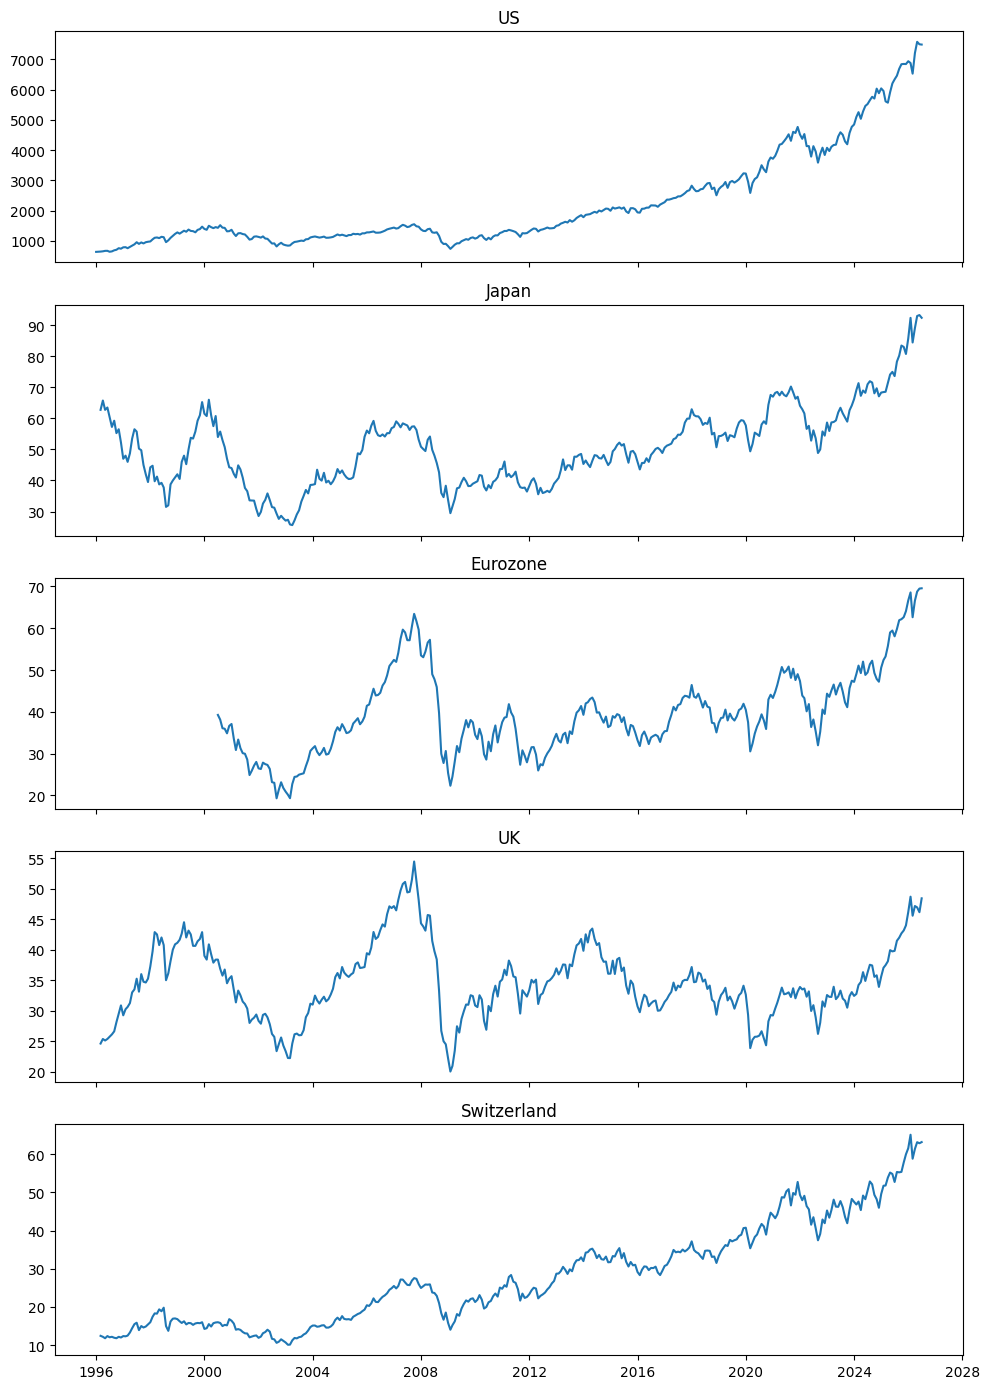

In [14]:
fig, axes = plt.subplots(5, 1, figsize=(10, 14), sharex=True)

for ax, (country, df) in zip(axes, market_prices.items()):
    ax.plot(df["Date"], df["Price"])
    ax.set_title(country)

plt.tight_layout()
plt.show()

In [15]:
market_prices_monthly = {}

for country, df in market_prices.items():
    temp = df.copy()
    temp["Month"] = temp["Date"].dt.to_period("M")
    market_prices_monthly[country] = temp[["Month", "Price"]].copy()

for country, df in market_prices_monthly.items():
    print(f"{country}: {len(df)} months, {df['Month'].min()} to {df['Month'].max()}")

US: 367 months, 1996-01 to 2026-07
Japan: 365 months, 1996-03 to 2026-07
Eurozone: 313 months, 2000-07 to 2026-07
UK: 365 months, 1996-03 to 2026-07
Switzerland: 365 months, 1996-03 to 2026-07


In [16]:
common_data_monthly = {}

for key, df in common_data.items():
    temp = df.copy()
    temp["Month"] = temp["Date"].dt.to_period("M")
    common_data_monthly[key] = temp

for country_key, macro_key in zip(
    ["Japan", "Eurozone", "UK", "Switzerland", "US"],
    ["JPY_raw_data.xlsx", "EUR_raw_data.xlsx", "UK_raw_data.xlsx",
     "CH_raw_data.xlsx", "US_raw_data.xlsx"]
):
    macro_months = set(common_data_monthly[macro_key]["Month"])
    price_months = set(market_prices_monthly[country_key]["Month"])
    overlap = macro_months & price_months

    print(
        f"{country_key}: macro={len(macro_months)}, "
        f"price={len(price_months)}, overlap={len(overlap)}"
    )

Japan: macro=245, price=365, overlap=245
Eurozone: macro=245, price=313, overlap=245
UK: macro=245, price=365, overlap=245
Switzerland: macro=245, price=365, overlap=245
US: macro=245, price=367, overlap=245


In [17]:
merged_data = {}

for country_key, macro_key in zip(
    ["Japan", "Eurozone", "UK", "Switzerland", "US"],
    ["JPY_raw_data.xlsx", "EUR_raw_data.xlsx", "UK_raw_data.xlsx",
     "CH_raw_data.xlsx", "US_raw_data.xlsx"]
):
    macro = common_data_monthly[macro_key]
    price = market_prices_monthly[country_key][["Month", "Price"]]

    merged = macro.merge(price, on="Month", how="inner")
    merged_data[country_key] = merged

    print(f"{country_key}: {merged.shape}")

Japan: (245, 12)
Eurozone: (245, 12)
UK: (245, 12)
Switzerland: (245, 13)
US: (245, 12)


In [18]:
frames = {}

for country, df in market_prices_monthly.items():
    temp = df.copy()
    temp["Date"] = temp["Month"].dt.to_timestamp(how="end").dt.normalize()
    frames[country] = temp.set_index("Date")["Price"]

price_matrix_full = pd.DataFrame(frames).sort_index()

print("Shape:", price_matrix_full.shape)
print("Missing values:")
print(price_matrix_full.isna().sum())

OUTPUT_DIR = "/content/drive/MyDrive/Crisil assessment/"
PRICE_MATRIX_PATH = f"{OUTPUT_DIR}price_matrix_full.csv"

price_matrix_full.to_csv(PRICE_MATRIX_PATH)
print("Saved:", PRICE_MATRIX_PATH)

Shape: (367, 5)
Missing values:
US              0
Japan           2
Eurozone       54
UK              2
Switzerland     2
dtype: int64
Saved: /content/drive/MyDrive/Crisil assessment/price_matrix_full.csv


In [19]:
for country_key, df in merged_data.items():
    path = f"{OUTPUT_DIR}{country_key}_common_with_price.csv"
    df.to_csv(path, index=False)
    print("Saved:", path)

Saved: /content/drive/MyDrive/Crisil assessment/Japan_common_with_price.csv
Saved: /content/drive/MyDrive/Crisil assessment/Eurozone_common_with_price.csv
Saved: /content/drive/MyDrive/Crisil assessment/UK_common_with_price.csv
Saved: /content/drive/MyDrive/Crisil assessment/Switzerland_common_with_price.csv
Saved: /content/drive/MyDrive/Crisil assessment/US_common_with_price.csv


## Macro Signal: PMI Level

PMI levels are pulled for each market and cross-sectionally standardized by date (`macro_score`), making the signal comparable across countries irrespective of each PMI series' own scale or history. The signal is validated independently of the scorecard using monthly Spearman rank IC against forward 3M and 6M returns (HAC-adjusted for serial correlation), and a top-minus-bottom country spread test to proxy the return to a long/short rotation strategy. Current positioning is read off the latest cross-sectional ranking.

PMI is used as the macro pillar because it is a timely, survey-based leading indicator of economic activity; expansion/contraction in manufacturing and services activity typically leads earnings revisions and risk appetite, giving it a plausible lead over equity performance at a 3-6 month horizon.

**Level vs. change:** The level is used directly rather than its month-over-month change, since the index is constructed around the 50 line as a real-time expansion/contraction threshold - the level itself is the state variable investors care about (is this economy currently expanding or contracting), and it surfaces ahead of official GDP releases, making it a genuine leading indicator in levels form rather than requiring a change transform to carry information.

In [20]:
# Macro signal: PMI level

OUTPUT_DIR = "/content/drive/MyDrive/Crisil assessment/"

country_pmi_map = {
    "US": ("US_common_with_price.csv", "NAPMPMI Index"),
    "Eurozone": ("Eurozone_common_with_price.csv", "MPMIEZMA Index"),
    "UK": ("UK_common_with_price.csv", "MPMIGBMA Index"),
    "Switzerland": ("Switzerland_common_with_price.csv", "CH_PMI"),
    "Japan": ("Japan_common_with_price.csv", "JPYPMI")
}


# Build PMI panel

frames = []

for country, (filename, pmi_col) in country_pmi_map.items():
    df = pd.read_csv(
        f"{OUTPUT_DIR}{filename}",
        parse_dates=["Date"]
    ).sort_values("Date").reset_index(drop=True)

    df["fwd_return_3m"] = df["Price"].shift(-3) / df["Price"] - 1
    df["fwd_return_6m"] = df["Price"].shift(-6) / df["Price"] - 1
    df["Country"] = country

    frames.append(
        df[
            ["Country", "Date", pmi_col, "Price",
             "fwd_return_3m", "fwd_return_6m"]
        ].rename(columns={pmi_col: "pmi_level"})
    )

pmi_panel = pd.concat(frames, ignore_index=True)

print("Panel:", pmi_panel.shape)
print("Countries:", pmi_panel["Country"].nunique())
print(
    "Date range:",
    pmi_panel["Date"].min().date(),
    "to",
    pmi_panel["Date"].max().date()
)


# Cross-sectional z-score

pmi_panel["macro_score"] = (
    pmi_panel.groupby("Date")["pmi_level"]
    .transform(lambda x: (x - x.mean()) / x.std())
)


# Monthly Spearman IC

def monthly_ic(signal_wide, return_wide):
    ic = {}

    for date in signal_wide.index:
        signal = signal_wide.loc[date].dropna()
        returns = return_wide.loc[date].dropna()
        common = signal.index.intersection(returns.index)

        if len(common) < 3:
            continue

        corr, _ = stats.spearmanr(
            signal[common],
            returns[common]
        )

        if not np.isnan(corr):
            ic[date] = corr

    return pd.Series(ic).sort_index()


def summarize_ic(ic_series, label, maxlags):
    ic_series = ic_series.dropna()

    model = sm.OLS(
        ic_series.values,
        np.ones(len(ic_series))
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": maxlags}
    )

    print(f"\n--- {label} ---")
    print(f"N months: {len(ic_series)}")
    print(f"Mean IC: {ic_series.mean():.4f}")
    print(f"Median IC: {ic_series.median():.4f}")
    print(f"IC hit rate: {(ic_series > 0).mean():.1%}")
    print(f"HAC t-stat: {model.tvalues[0]:.3f}")
    print(f"p-value: {model.pvalues[0]:.4f}")

    return ic_series


# Top-minus-bottom spread

def top_bottom_spread(signal_wide, return_wide):
    spreads = {}

    for date in signal_wide.index:
        signal = signal_wide.loc[date].dropna()
        returns = return_wide.loc[date]

        if len(signal) < 2:
            continue

        top_country = signal.idxmax()
        bottom_country = signal.idxmin()

        if (
            pd.isna(returns.get(top_country))
            or pd.isna(returns.get(bottom_country))
        ):
            continue

        spreads[date] = (
            returns[top_country] - returns[bottom_country]
        )

    return pd.Series(spreads).sort_index()


def summarize_spread(
    spread_series,
    label,
    maxlags,
    periods_per_year
):
    spread_series = spread_series.dropna()

    model = sm.OLS(
        spread_series.values,
        np.ones(len(spread_series))
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": maxlags}
    )

    mean_spread = spread_series.mean()
    annualized_return = mean_spread * periods_per_year
    annualized_vol = spread_series.std() * np.sqrt(periods_per_year)

    sharpe = (
        annualized_return / annualized_vol
        if annualized_vol > 0
        else np.nan
    )

    print(f"\n--- {label} ---")
    print(f"N months: {len(spread_series)}")
    print(f"Mean spread: {mean_spread:.4f}")
    print(f"Hit rate: {(spread_series > 0).mean():.1%}")
    print(f"Approx. annualized Sharpe: {sharpe:.2f}")
    print(f"HAC t-stat: {model.tvalues[0]:.3f}")
    print(f"p-value: {model.pvalues[0]:.4f}")


# Cross-sectional matrices

signal_wide = pmi_panel.pivot(
    index="Date",
    columns="Country",
    values="macro_score"
)

ret3_wide = pmi_panel.pivot(
    index="Date",
    columns="Country",
    values="fwd_return_3m"
)

ret6_wide = pmi_panel.pivot(
    index="Date",
    columns="Country",
    values="fwd_return_6m"
)


# Information coefficient

print("\n" + "=" * 60)
print("MACRO SIGNAL — MONTHLY CROSS-SECTIONAL INFORMATION COEFFICIENT")
print("=" * 60)

ic_3m = monthly_ic(signal_wide, ret3_wide)
ic_6m = monthly_ic(signal_wide, ret6_wide)

summarize_ic(
    ic_3m,
    "PMI Level vs 3M forward return",
    maxlags=3
)

summarize_ic(
    ic_6m,
    "PMI Level vs 6M forward return",
    maxlags=6
)


# Top-minus-bottom test

spread_3m = top_bottom_spread(signal_wide, ret3_wide)
spread_6m = top_bottom_spread(signal_wide, ret6_wide)

print("\n" + "=" * 60)
print("MACRO SIGNAL — TOP-MINUS-BOTTOM COUNTRY SPREAD")
print("=" * 60)

summarize_spread(
    spread_3m,
    "PMI top-minus-bottom, 3M return",
    maxlags=3,
    periods_per_year=4
)

summarize_spread(
    spread_6m,
    "PMI top-minus-bottom, 6M return",
    maxlags=6,
    periods_per_year=2
)


# Latest available month

latest_date = pmi_panel["Date"].max()

latest = (
    pmi_panel[
        pmi_panel["Date"] == latest_date
    ][
        ["Country", "pmi_level", "macro_score"]
    ]
    .copy()
)

latest["rank"] = latest["macro_score"].rank(
    ascending=False,
    method="min"
)

latest = (
    latest
    .sort_values("rank")
    .reset_index(drop=True)
)

print("\n" + "=" * 60)
print(f"MACRO PILLAR — LATEST MONTH ({latest_date.date()})")
print("=" * 60)

print(latest.to_string(index=False))

Panel: (1225, 6)
Countries: 5
Date range: 2005-12-30 to 2026-04-30

MACRO SIGNAL — MONTHLY CROSS-SECTIONAL INFORMATION COEFFICIENT

--- PMI Level vs 3M forward return ---
N months: 242
Mean IC: 0.0685
Median IC: 0.1000
IC hit rate: 54.5%
HAC t-stat: 1.499
p-value: 0.1340

--- PMI Level vs 6M forward return ---
N months: 239
Mean IC: 0.0757
Median IC: 0.1000
IC hit rate: 53.6%
HAC t-stat: 1.193
p-value: 0.2330

MACRO SIGNAL — TOP-MINUS-BOTTOM COUNTRY SPREAD

--- PMI top-minus-bottom, 3M return ---
N months: 242
Mean spread: 0.0079
Hit rate: 56.6%
Approx. annualized Sharpe: 0.25
HAC t-stat: 1.378
p-value: 0.1681

--- PMI top-minus-bottom, 6M return ---
N months: 239
Mean spread: 0.0130
Hit rate: 57.3%
Approx. annualized Sharpe: 0.22
HAC t-stat: 1.425
p-value: 0.1542

MACRO PILLAR — LATEST MONTH (2026-04-30)
    Country  pmi_level  macro_score  rank
      Japan       55.1     1.182166   1.0
Switzerland       54.5     0.709299   2.0
         UK       53.7     0.078811   3.0
         US    

# Micro Signal: 6-Month EPS Growth

Six-month consensus EPS growth is computed per country (`eps_growth_6m`) and cross-sectionally standardized by date (`micro_score`), making it comparable across countries independent of each market's absolute earnings level. The signal is validated using monthly Spearman rank IC against forward 3M and 6M returns (HAC-adjusted), and a top-minus-bottom country spread test.

EPS growth is used as the micro pillar because equity prices are ultimately a function of corporate earnings and the multiple applied to them; it is the bottom-up, company-level complement to the top-down, economy-wide PMI signal. A market where aggregate forward earnings are growing faster than peers reflects stronger underlying corporate fundamentals - improving margins, revenue growth, or operating leverage - which supports higher equity valuations independent of any macro or price-based consideration. Markets with superior relative earnings growth are therefore expected to see relative price outperformance as fundamentals improve.

In [21]:
# Micro signal: 6-month EPS growth

OUTPUT_DIR = "/content/drive/MyDrive/Crisil assessment/"

country_eps_map = {
    "US": ("US_common_with_price.csv", "Monthly_EPS"),
    "Eurozone": ("Eurozone_common_with_price.csv", "BEst EPS"),
    "UK": ("UK_common_with_price.csv", "BEst EPS"),
    "Switzerland": ("Switzerland_common_with_price.csv", "BEst EPS"),
    "Japan": ("Japan_common_with_price.csv", "BEst EPS")
}


# Build EPS panel

frames = []

for country, (filename, eps_col) in country_eps_map.items():
    df = pd.read_csv(
        f"{OUTPUT_DIR}{filename}",
        parse_dates=["Date"]
    ).sort_values("Date").reset_index(drop=True)

    df["fwd_return_3m"] = df["Price"].shift(-3) / df["Price"] - 1
    df["fwd_return_6m"] = df["Price"].shift(-6) / df["Price"] - 1

    df["eps_growth_6m"] = (
        df[eps_col] / df[eps_col].shift(6) - 1
    )

    df["Country"] = country

    frames.append(
        df[
            ["Country", "Date", "eps_growth_6m", "Price",
             "fwd_return_3m", "fwd_return_6m"]
        ]
    )

eps_panel = pd.concat(frames, ignore_index=True)

print("Panel:", eps_panel.shape)
print("Countries:", eps_panel["Country"].nunique())
print(
    "Date range:",
    eps_panel["Date"].min().date(),
    "to",
    eps_panel["Date"].max().date()
)


# Cross-sectional z-score

eps_panel["micro_score"] = (
    eps_panel.groupby("Date")["eps_growth_6m"]
    .transform(lambda x: (x - x.mean()) / x.std())
)


# Monthly Spearman IC

def monthly_ic(signal_wide, return_wide):
    ic = {}

    for date in signal_wide.index:
        signal = signal_wide.loc[date].dropna()
        returns = return_wide.loc[date].dropna()
        common = signal.index.intersection(returns.index)

        if len(common) < 3:
            continue

        corr, _ = stats.spearmanr(
            signal[common],
            returns[common]
        )

        if not np.isnan(corr):
            ic[date] = corr

    return pd.Series(ic).sort_index()


def summarize_ic(ic_series, label, maxlags):
    ic_series = ic_series.dropna()

    model = sm.OLS(
        ic_series.values,
        np.ones(len(ic_series))
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": maxlags}
    )

    print(f"\n--- {label} ---")
    print(f"N months: {len(ic_series)}")
    print(f"Mean IC: {ic_series.mean():.4f}")
    print(f"Median IC: {ic_series.median():.4f}")
    print(f"IC hit rate: {(ic_series > 0).mean():.1%}")
    print(f"HAC t-stat: {model.tvalues[0]:.3f}")
    print(f"p-value: {model.pvalues[0]:.4f}")

    return ic_series


# Top-minus-bottom spread

def top_bottom_spread(signal_wide, return_wide):
    spreads = {}

    for date in signal_wide.index:
        signal = signal_wide.loc[date].dropna()
        returns = return_wide.loc[date]

        if len(signal) < 2:
            continue

        top_country = signal.idxmax()
        bottom_country = signal.idxmin()

        if (
            pd.isna(returns.get(top_country))
            or pd.isna(returns.get(bottom_country))
        ):
            continue

        spreads[date] = (
            returns[top_country] - returns[bottom_country]
        )

    return pd.Series(spreads).sort_index()


def summarize_spread(
    spread_series,
    label,
    maxlags,
    periods_per_year
):
    spread_series = spread_series.dropna()

    model = sm.OLS(
        spread_series.values,
        np.ones(len(spread_series))
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": maxlags}
    )

    mean_spread = spread_series.mean()
    annualized_return = mean_spread * periods_per_year
    annualized_vol = spread_series.std() * np.sqrt(periods_per_year)

    sharpe = (
        annualized_return / annualized_vol
        if annualized_vol > 0
        else np.nan
    )

    print(f"\n--- {label} ---")
    print(f"N months: {len(spread_series)}")
    print(f"Mean spread: {mean_spread:.4f}")
    print(f"Hit rate: {(spread_series > 0).mean():.1%}")
    print(f"Approx. annualized Sharpe: {sharpe:.2f}")
    print(f"HAC t-stat: {model.tvalues[0]:.3f}")
    print(f"p-value: {model.pvalues[0]:.4f}")


# Cross-sectional matrices

signal_wide = eps_panel.pivot(
    index="Date",
    columns="Country",
    values="micro_score"
)

ret3_wide = eps_panel.pivot(
    index="Date",
    columns="Country",
    values="fwd_return_3m"
)

ret6_wide = eps_panel.pivot(
    index="Date",
    columns="Country",
    values="fwd_return_6m"
)


# Information coefficient

print("\n" + "=" * 60)
print("MICRO SIGNAL — MONTHLY CROSS-SECTIONAL INFORMATION COEFFICIENT")
print("=" * 60)

ic_3m = monthly_ic(signal_wide, ret3_wide)
ic_6m = monthly_ic(signal_wide, ret6_wide)

summarize_ic(
    ic_3m,
    "6M EPS Growth vs 3M forward return",
    maxlags=3
)

summarize_ic(
    ic_6m,
    "6M EPS Growth vs 6M forward return",
    maxlags=6
)


# Top-minus-bottom test

spread_3m = top_bottom_spread(signal_wide, ret3_wide)
spread_6m = top_bottom_spread(signal_wide, ret6_wide)

print("\n" + "=" * 60)
print("MICRO SIGNAL — TOP-MINUS-BOTTOM COUNTRY SPREAD")
print("=" * 60)

summarize_spread(
    spread_3m,
    "6M EPS Growth top-minus-bottom, 3M return",
    maxlags=3,
    periods_per_year=4
)

summarize_spread(
    spread_6m,
    "6M EPS Growth top-minus-bottom, 6M return",
    maxlags=6,
    periods_per_year=2
)


# Latest available month

latest_date = eps_panel["Date"].max()

latest = (
    eps_panel[
        eps_panel["Date"] == latest_date
    ][
        ["Country", "eps_growth_6m", "micro_score"]
    ]
    .copy()
)

latest["rank"] = latest["micro_score"].rank(
    ascending=False,
    method="min"
)

latest = (
    latest
    .sort_values("rank")
    .reset_index(drop=True)
)

print("\n" + "=" * 60)
print(f"MICRO PILLAR — LATEST MONTH ({latest_date.date()})")
print("=" * 60)

print(latest.to_string(index=False))

Panel: (1225, 6)
Countries: 5
Date range: 2005-12-30 to 2026-04-30

MICRO SIGNAL — MONTHLY CROSS-SECTIONAL INFORMATION COEFFICIENT

--- 6M EPS Growth vs 3M forward return ---
N months: 236
Mean IC: 0.1314
Median IC: 0.2000
IC hit rate: 59.3%
HAC t-stat: 2.606
p-value: 0.0092

--- 6M EPS Growth vs 6M forward return ---
N months: 233
Mean IC: 0.1446
Median IC: 0.2000
IC hit rate: 57.9%
HAC t-stat: 2.131
p-value: 0.0331

MICRO SIGNAL — TOP-MINUS-BOTTOM COUNTRY SPREAD

--- 6M EPS Growth top-minus-bottom, 3M return ---
N months: 236
Mean spread: 0.0110
Hit rate: 60.2%
Approx. annualized Sharpe: 0.35
HAC t-stat: 1.849
p-value: 0.0644

--- 6M EPS Growth top-minus-bottom, 6M return ---
N months: 233
Mean spread: 0.0204
Hit rate: 58.4%
Approx. annualized Sharpe: 0.33
HAC t-stat: 1.920
p-value: 0.0548

MICRO PILLAR — LATEST MONTH (2026-04-30)
    Country  eps_growth_6m  micro_score  rank
         US       0.164654     1.265199   1.0
         UK       0.116854     0.406880   2.0
      Japan      

## Valuation Signal: 6-Month P/E Change

Six-month forward P/E change is computed per country (`pe_change_6m`), and the signal is defined as its negative (`valuation_signal = -pe_change_6m`), then cross-sectionally standardized by date. The signal is validated using monthly Spearman rank IC against forward 3M and 6M returns (HAC-adjusted), and a top-minus-bottom country spread test.

Forward P/E - price relative to consensus forward earnings - is a standard value-style characteristic used to define equity value indexes, and is inverted here because relative valuations mean-revert: a market whose multiple has recently compressed is more likely to see that gap close through price recovery than keep compounding the de-rating, making multiple compression a contrarian signal rather than a random walk. The sign is flipped so the variable follows the same "higher = more bullish" convention as the other three pillars - a compressing multiple (negative `pe_change_6m`) produces a positive `valuation_signal`, keeping polarity consistent across the composite score.

In [22]:
# Valuation signal: 6-month P/E change

OUTPUT_DIR = "/content/drive/MyDrive/Crisil assessment/"

country_pe_map = {
    "US": ("US_common_with_price.csv", "BEst P/E Ratio"),
    "Eurozone": ("Eurozone_common_with_price.csv", "BEst P/E Ratio"),
    "UK": ("UK_common_with_price.csv", "BEst P/E Ratio"),
    "Switzerland": ("Switzerland_common_with_price.csv", "BEst P/E Ratio"),
    "Japan": ("Japan_common_with_price.csv", "BEst P/E Ratio")
}


# Build valuation panel

frames = []

for country, (filename, pe_col) in country_pe_map.items():
    df = pd.read_csv(
        f"{OUTPUT_DIR}{filename}",
        parse_dates=["Date"]
    ).sort_values("Date").reset_index(drop=True)

    df[pe_col] = pd.to_numeric(df[pe_col], errors="coerce")

    df["fwd_return_3m"] = df["Price"].shift(-3) / df["Price"] - 1
    df["fwd_return_6m"] = df["Price"].shift(-6) / df["Price"] - 1

    df["pe_change_6m"] = df[pe_col] / df[pe_col].shift(6) - 1
    df["valuation_signal"] = -df["pe_change_6m"]

    df["Country"] = country

    frames.append(
        df[
            ["Country", "Date", "pe_change_6m", "valuation_signal",
             "Price", "fwd_return_3m", "fwd_return_6m"]
        ]
    )

valuation_panel = pd.concat(frames, ignore_index=True)

print("Panel:", valuation_panel.shape)
print("Countries:", valuation_panel["Country"].nunique())
print(
    "Date range:",
    valuation_panel["Date"].min().date(),
    "to",
    valuation_panel["Date"].max().date()
)


# Cross-sectional z-score

valuation_panel["valuation_score"] = (
    valuation_panel.groupby("Date")["valuation_signal"]
    .transform(lambda x: (x - x.mean()) / x.std())
)


# Monthly Spearman IC

def monthly_ic(signal_wide, return_wide):
    ic = {}

    for date in signal_wide.index:
        signal = signal_wide.loc[date].dropna()
        returns = return_wide.loc[date].dropna()
        common = signal.index.intersection(returns.index)

        if len(common) < 3:
            continue

        corr, _ = stats.spearmanr(
            signal[common],
            returns[common]
        )

        if not np.isnan(corr):
            ic[date] = corr

    return pd.Series(ic).sort_index()


def summarize_ic(ic_series, label, maxlags):
    ic_series = ic_series.dropna()

    model = sm.OLS(
        ic_series.values,
        np.ones(len(ic_series))
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": maxlags}
    )

    print(f"\n--- {label} ---")
    print(f"N months: {len(ic_series)}")
    print(f"Mean IC: {ic_series.mean():.4f}")
    print(f"Median IC: {ic_series.median():.4f}")
    print(f"IC hit rate: {(ic_series > 0).mean():.1%}")
    print(f"HAC t-stat: {model.tvalues[0]:.3f}")
    print(f"p-value: {model.pvalues[0]:.4f}")

    return ic_series


# Top-minus-bottom spread

def top_bottom_spread(signal_wide, return_wide):
    spreads = {}

    for date in signal_wide.index:
        signal = signal_wide.loc[date].dropna()
        returns = return_wide.loc[date]

        if len(signal) < 2:
            continue

        top_country = signal.idxmax()
        bottom_country = signal.idxmin()

        if (
            pd.isna(returns.get(top_country))
            or pd.isna(returns.get(bottom_country))
        ):
            continue

        spreads[date] = (
            returns[top_country] - returns[bottom_country]
        )

    return pd.Series(spreads).sort_index()


def summarize_spread(
    spread_series,
    label,
    maxlags,
    periods_per_year
):
    spread_series = spread_series.dropna()

    model = sm.OLS(
        spread_series.values,
        np.ones(len(spread_series))
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": maxlags}
    )

    mean_spread = spread_series.mean()
    annualized_return = mean_spread * periods_per_year
    annualized_vol = spread_series.std() * np.sqrt(periods_per_year)

    sharpe = (
        annualized_return / annualized_vol
        if annualized_vol > 0
        else np.nan
    )

    print(f"\n--- {label} ---")
    print(f"N months: {len(spread_series)}")
    print(f"Mean spread: {mean_spread:.4f}")
    print(f"Hit rate: {(spread_series > 0).mean():.1%}")
    print(f"Approx. annualized Sharpe: {sharpe:.2f}")
    print(f"HAC t-stat: {model.tvalues[0]:.3f}")
    print(f"p-value: {model.pvalues[0]:.4f}")


# Cross-sectional matrices

signal_wide = valuation_panel.pivot(
    index="Date",
    columns="Country",
    values="valuation_score"
)

ret3_wide = valuation_panel.pivot(
    index="Date",
    columns="Country",
    values="fwd_return_3m"
)

ret6_wide = valuation_panel.pivot(
    index="Date",
    columns="Country",
    values="fwd_return_6m"
)


# Information coefficient

print("\n" + "=" * 60)
print("VALUATION SIGNAL — MONTHLY CROSS-SECTIONAL INFORMATION COEFFICIENT")
print("=" * 60)

ic_3m = monthly_ic(signal_wide, ret3_wide)
ic_6m = monthly_ic(signal_wide, ret6_wide)

summarize_ic(
    ic_3m,
    "6M P/E Change vs 3M forward return",
    maxlags=3
)

summarize_ic(
    ic_6m,
    "6M P/E Change vs 6M forward return",
    maxlags=6
)


# Top-minus-bottom test

spread_3m = top_bottom_spread(signal_wide, ret3_wide)
spread_6m = top_bottom_spread(signal_wide, ret6_wide)

print("\n" + "=" * 60)
print("VALUATION SIGNAL — TOP-MINUS-BOTTOM COUNTRY SPREAD")
print("=" * 60)

summarize_spread(
    spread_3m,
    "6M P/E Change top-minus-bottom, 3M return",
    maxlags=3,
    periods_per_year=4
)

summarize_spread(
    spread_6m,
    "6M P/E Change top-minus-bottom, 6M return",
    maxlags=6,
    periods_per_year=2
)


# Latest available month

latest_date = valuation_panel["Date"].max()

latest = (
    valuation_panel[
        valuation_panel["Date"] == latest_date
    ][
        ["Country", "pe_change_6m", "valuation_signal", "valuation_score"]
    ]
    .copy()
)

latest["rank"] = latest["valuation_score"].rank(
    ascending=False,
    method="min"
)

latest = (
    latest
    .sort_values("rank")
    .reset_index(drop=True)
)

print("\n" + "=" * 60)
print(f"VALUATION PILLAR — LATEST MONTH ({latest_date.date()})")
print("=" * 60)

print(latest.to_string(index=False))

Panel: (1225, 7)
Countries: 5
Date range: 2005-12-30 to 2026-04-30

VALUATION SIGNAL — MONTHLY CROSS-SECTIONAL INFORMATION COEFFICIENT

--- 6M P/E Change vs 3M forward return ---
N months: 236
Mean IC: 0.0500
Median IC: 0.0000
IC hit rate: 49.2%
HAC t-stat: 1.189
p-value: 0.2343

--- 6M P/E Change vs 6M forward return ---
N months: 233
Mean IC: 0.0408
Median IC: 0.1000
IC hit rate: 51.1%
HAC t-stat: 0.740
p-value: 0.4592

VALUATION SIGNAL — TOP-MINUS-BOTTOM COUNTRY SPREAD

--- 6M P/E Change top-minus-bottom, 3M return ---
N months: 236
Mean spread: 0.0079
Hit rate: 53.8%
Approx. annualized Sharpe: 0.28
HAC t-stat: 1.817
p-value: 0.0693

--- 6M P/E Change top-minus-bottom, 6M return ---
N months: 233
Mean spread: 0.0080
Hit rate: 52.4%
Approx. annualized Sharpe: 0.14
HAC t-stat: 0.915
p-value: 0.3602

VALUATION PILLAR — LATEST MONTH (2026-04-30)
    Country  pe_change_6m  valuation_signal  valuation_score  rank
         US     -0.095731          0.095731         1.405257   1.0
         




# Technical Signal: 6-Month Risk-Adjusted Momentum

Price momentum is computed as the 6-month return excluding the most recent month (`Mom_6M_ex1M`, skipping the 1-month reversal window), scaled by trailing 12-month realized volatility (`Vol_12M`) to give `RAMom_6M`, then cross-sectionally standardized by date. The signal is validated using monthly Spearman rank IC against forward 3M and 6M returns (HAC-adjusted), and a top-minus-bottom country spread test.

This mirrors standard factor-index momentum construction: excluding the most recent month avoids the well-documented short-term reversal effect, and scaling by realized volatility controls for the fact that raw returns mechanically favor high-volatility markets, reducing exposure to sharp momentum crashes and isolating trend persistence per unit of risk


In [23]:
# Technical signal: 6-month risk-adjusted momentum

import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import spearmanr

BASE_PATH = "/content/drive/MyDrive/Crisil assessment"

COUNTRY_FILES = {
    "US": f"{BASE_PATH}/US_common_with_price.csv",
    "Japan": f"{BASE_PATH}/Japan_common_with_price.csv",
    "Eurozone": f"{BASE_PATH}/Eurozone_common_with_price.csv",
    "UK": f"{BASE_PATH}/UK_common_with_price.csv",
    "Switzerland": f"{BASE_PATH}/Switzerland_common_with_price.csv"
}


# Build price panel

frames = []

for country, file in COUNTRY_FILES.items():
    df = pd.read_csv(
        file,
        parse_dates=["Date"]
    ).sort_values("Date").reset_index(drop=True)

    df["Forward_3M"] = df["Price"].shift(-3) / df["Price"] - 1
    df["Forward_6M"] = df["Price"].shift(-6) / df["Price"] - 1

    df["Monthly_Return"] = df["Price"].pct_change()

    df["Vol_12M"] = (
        df["Monthly_Return"]
        .rolling(12, min_periods=12)
        .std() * np.sqrt(12)
    )

    df["Mom_6M_ex1M"] = (
        df["Price"].shift(1)
        / df["Price"].shift(7)
        - 1
    )

    df["RAMom_6M"] = (
        df["Mom_6M_ex1M"] / df["Vol_12M"]
    )

    df["Country"] = country

    frames.append(
        df[
            [
                "Country",
                "Date",
                "Mom_6M_ex1M",
                "Vol_12M",
                "RAMom_6M",
                "Price",
                "Forward_3M",
                "Forward_6M"
            ]
        ]
    )

technical_panel = pd.concat(
    frames,
    ignore_index=True
)

print("Panel:", technical_panel.shape)
print("Countries:", technical_panel["Country"].nunique())
print(
    "Date range:",
    technical_panel["Date"].min().date(),
    "to",
    technical_panel["Date"].max().date()
)


# Cross-sectional z-score

technical_panel["Technical_Score"] = (
    technical_panel.groupby("Date")["RAMom_6M"]
    .transform(
        lambda x: (
            x - x.mean()
        ) / x.std()
    )
)


# Monthly Spearman IC

def monthly_ic(signal_col, return_col):
    ic = {}

    for date, group in technical_panel.groupby("Date"):
        data = group[[signal_col, return_col]].dropna()

        if len(data) < 3:
            continue

        corr, _ = spearmanr(
            data[signal_col],
            data[return_col]
        )

        if not np.isnan(corr):
            ic[date] = corr

    return pd.Series(ic).sort_index()


def summarize_ic(ic_series, label, maxlags):
    ic_series = ic_series.dropna()

    model = sm.OLS(
        ic_series.values,
        np.ones(len(ic_series))
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": maxlags}
    )

    print(f"\n--- {label} ---")
    print(f"N months: {len(ic_series)}")
    print(f"Mean IC: {ic_series.mean():.4f}")
    print(f"Median IC: {ic_series.median():.4f}")
    print(f"IC hit rate: {(ic_series > 0).mean():.1%}")
    print(f"HAC t-stat: {model.tvalues[0]:.3f}")
    print(f"p-value: {model.pvalues[0]:.4f}")

    return ic_series


ic_3m = monthly_ic(
    "Technical_Score",
    "Forward_3M"
)

ic_6m = monthly_ic(
    "Technical_Score",
    "Forward_6M"
)

print("\n" + "=" * 60)
print("TECHNICAL SIGNAL — MONTHLY CROSS-SECTIONAL IC")
print("=" * 60)

summarize_ic(
    ic_3m,
    "6M Risk-adjusted momentum vs 3M forward return",
    maxlags=3
)

summarize_ic(
    ic_6m,
    "6M Risk-adjusted momentum vs 6M forward return",
    maxlags=6
)


# Top-minus-bottom spread

def top_bottom_spread(return_col):
    spreads = {}

    for date, group in technical_panel.groupby("Date"):
        data = group[["Technical_Score", return_col]].dropna()

        if len(data) < 5:
            continue

        data = data.sort_values("Technical_Score")

        spreads[date] = (
            data.iloc[-1][return_col]
            - data.iloc[0][return_col]
        )

    return pd.Series(spreads).sort_index()


def summarize_spread(
    spread_series,
    label,
    maxlags,
    periods_per_year
):
    spread_series = spread_series.dropna()

    model = sm.OLS(
        spread_series.values,
        np.ones(len(spread_series))
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": maxlags}
    )

    mean_spread = spread_series.mean()
    annualized_return = mean_spread * periods_per_year
    annualized_vol = spread_series.std() * np.sqrt(periods_per_year)

    sharpe = (
        annualized_return / annualized_vol
        if annualized_vol > 0
        else np.nan
    )

    print(f"\n--- {label} ---")
    print(f"N months: {len(spread_series)}")
    print(f"Mean spread: {mean_spread:.4f}")
    print(f"Hit rate: {(spread_series > 0).mean():.1%}")
    print(f"Approx. annualized Sharpe: {sharpe:.2f}")
    print(f"HAC t-stat: {model.tvalues[0]:.3f}")
    print(f"p-value: {model.pvalues[0]:.4f}")


spread_3m = top_bottom_spread("Forward_3M")
spread_6m = top_bottom_spread("Forward_6M")

print("\n" + "=" * 60)
print("TECHNICAL SIGNAL — TOP-MINUS-BOTTOM SPREAD")
print("=" * 60)

summarize_spread(
    spread_3m,
    "6M Risk-adjusted momentum top-minus-bottom, 3M return",
    maxlags=3,
    periods_per_year=4
)

summarize_spread(
    spread_6m,
    "6M Risk-adjusted momentum top-minus-bottom, 6M return",
    maxlags=6,
    periods_per_year=2
)


# Latest available month

latest_date = technical_panel["Date"].max()

latest = (
    technical_panel[
        technical_panel["Date"] == latest_date
    ][
        [
            "Country",
            "Mom_6M_ex1M",
            "Vol_12M",
            "RAMom_6M",
            "Technical_Score"
        ]
    ]
    .copy()
)

latest["rank"] = latest["Technical_Score"].rank(
    ascending=False,
    method="min"
)

latest = (
    latest
    .sort_values("rank")
    .reset_index(drop=True)
)

print("\n" + "=" * 60)
print(f"TECHNICAL PILLAR — LATEST MONTH ({latest_date.date()})")
print("=" * 60)

print(latest.to_string(index=False))

Panel: (1225, 8)
Countries: 5
Date range: 2005-12-30 to 2026-04-30

TECHNICAL SIGNAL — MONTHLY CROSS-SECTIONAL IC

--- 6M Risk-adjusted momentum vs 3M forward return ---
N months: 230
Mean IC: 0.0078
Median IC: 0.1000
IC hit rate: 50.9%
HAC t-stat: 0.163
p-value: 0.8708

--- 6M Risk-adjusted momentum vs 6M forward return ---
N months: 227
Mean IC: 0.0648
Median IC: 0.1000
IC hit rate: 52.0%
HAC t-stat: 1.053
p-value: 0.2925

TECHNICAL SIGNAL — TOP-MINUS-BOTTOM SPREAD

--- 6M Risk-adjusted momentum top-minus-bottom, 3M return ---
N months: 230
Mean spread: -0.0050
Hit rate: 46.1%
Approx. annualized Sharpe: -0.16
HAC t-stat: -0.869
p-value: 0.3847

--- 6M Risk-adjusted momentum top-minus-bottom, 6M return ---
N months: 227
Mean spread: 0.0052
Hit rate: 51.5%
Approx. annualized Sharpe: 0.08
HAC t-stat: 0.528
p-value: 0.5972

TECHNICAL PILLAR — LATEST MONTH (2026-04-30)
    Country  Mom_6M_ex1M  Vol_12M  RAMom_6M  Technical_Score  rank
         UK     0.085537 0.112747  0.758667         1.

# Scorecard Construction

Each of the four signals - PMI, 6M EPS growth, 6M P/E change (inverted), and 6M risk-adjusted momentum - is cross-sectionally standardized by date into Macro_Score, Micro_Score, Valuation_Score, and Technical_Score. These pillar scores are combined into a single Composite_Score per country per date using equal weights (25% each), reflecting no prior view on which pillar dominates. Countries are ranked each month by Composite_Score to produce the monthly cross-sectional ranking used for the investment view.

In [24]:
# Final Developed Markets Scorecard
# Markets: US, Japan, Eurozone, UK, Switzerland
# Pillars: PMI, 6M EPS Growth, 6M P/E Change, 6M Risk-Adjusted Momentum
# Equal weights: 25% each

BASE_PATH = "/content/drive/MyDrive/Crisil assessment"

COUNTRY_FILES = {
    "US": f"{BASE_PATH}/US_common_with_price.csv",
    "Japan": f"{BASE_PATH}/Japan_common_with_price.csv",
    "Eurozone": f"{BASE_PATH}/Eurozone_common_with_price.csv",
    "UK": f"{BASE_PATH}/UK_common_with_price.csv",
    "Switzerland": f"{BASE_PATH}/Switzerland_common_with_price.csv"
}

W_MACRO = 0.25
W_MICRO = 0.25
W_VALUATION = 0.25
W_TECHNICAL = 0.25


COLUMN_MAP = {
    "US": {
        "PMI": "NAPMPMI Index",
        "EPS": "Monthly_EPS",
        "PE": "BEst P/E Ratio",
        "PRICE": "Price"
    },
    "Japan": {
        "PMI": "JPYPMI",
        "EPS": "BEst EPS",
        "PE": "BEst P/E Ratio",
        "PRICE": "Price"
    },
    "Eurozone": {
        "PMI": "MPMIEZMA Index",
        "EPS": "BEst EPS",
        "PE": "BEst P/E Ratio",
        "PRICE": "Price"
    },
    "UK": {
        "PMI": "MPMIGBMA Index",
        "EPS": "BEst EPS",
        "PE": "BEst P/E Ratio",
        "PRICE": "Price"
    },
    "Switzerland": {
        "PMI": "CH_PMI",
        "EPS": "BEst EPS",
        "PE": "BEst P/E Ratio",
        "PRICE": "Price"
    }
}


# Load country data

country_data = {}

for country, file in COUNTRY_FILES.items():
    df = pd.read_csv(file)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    df = df[
        [
            "Date",
            COLUMN_MAP[country]["PMI"],
            COLUMN_MAP[country]["EPS"],
            COLUMN_MAP[country]["PE"],
            COLUMN_MAP[country]["PRICE"]
        ]
    ].copy()

    df.columns = [
        "Date",
        "PMI",
        "EPS",
        "PE",
        "Price"
    ]

    df["Country"] = country
    country_data[country] = df


scorecard_panel = pd.concat(
    country_data.values(),
    ignore_index=True
)

scorecard_panel = (
    scorecard_panel
    .sort_values(["Country", "Date"])
    .reset_index(drop=True)
)

print("Panel shape:", scorecard_panel.shape)
print("Countries:", scorecard_panel["Country"].nunique())
print(
    "Date range:",
    scorecard_panel["Date"].min().date(),
    "to",
    scorecard_panel["Date"].max().date()
)


# Forward returns

scorecard_panel["Forward_3M"] = (
    scorecard_panel.groupby("Country")["Price"].shift(-3)
    / scorecard_panel["Price"]
    - 1
)

scorecard_panel["Forward_6M"] = (
    scorecard_panel.groupby("Country")["Price"].shift(-6)
    / scorecard_panel["Price"]
    - 1
)


# Macro: PMI level

scorecard_panel["Macro_Signal"] = scorecard_panel["PMI"]


# Micro: 6M EPS growth

scorecard_panel["Micro_Signal"] = (
    scorecard_panel
    .groupby("Country")["EPS"]
    .pct_change(6)
)


# Valuation: 6M change in forward P/E

scorecard_panel["PE_6M_Change"] = (
    scorecard_panel
    .groupby("Country")["PE"]
    .pct_change(6)
)

scorecard_panel["Valuation_Signal"] = (
    -scorecard_panel["PE_6M_Change"]
)


# Technical: 6M risk-adjusted momentum

scorecard_panel["Monthly_Return"] = (
    scorecard_panel
    .groupby("Country")["Price"]
    .pct_change()
)

scorecard_panel["Vol_12M"] = (
    scorecard_panel
    .groupby("Country")["Monthly_Return"]
    .transform(
        lambda x: x.rolling(12, min_periods=12).std() * np.sqrt(12)
    )
)

scorecard_panel["Mom_6M_ex1M"] = (
    scorecard_panel.groupby("Country")["Price"].shift(1)
    / scorecard_panel.groupby("Country")["Price"].shift(7)
    - 1
)

scorecard_panel["Technical_Signal"] = (
    scorecard_panel["Mom_6M_ex1M"]
    / scorecard_panel["Vol_12M"]
)


# Monthly cross-sectional z-score

def cross_sectional_zscore(x):
    std = x.std()

    if pd.isna(std) or std == 0:
        return np.nan

    return (x - x.mean()) / std


for signal, score in [
    ("Macro_Signal", "Macro_Score"),
    ("Micro_Signal", "Micro_Score"),
    ("Valuation_Signal", "Valuation_Score"),
    ("Technical_Signal", "Technical_Score")
]:
    scorecard_panel[score] = (
        scorecard_panel
        .groupby("Date")[signal]
        .transform(cross_sectional_zscore)
    )


# Equal-weight composite

scorecard_panel["Composite_Score"] = (
    W_MACRO * scorecard_panel["Macro_Score"]
    + W_MICRO * scorecard_panel["Micro_Score"]
    + W_VALUATION * scorecard_panel["Valuation_Score"]
    + W_TECHNICAL * scorecard_panel["Technical_Score"]
)


# Monthly country ranking

scorecard_panel["Country_Rank"] = (
    scorecard_panel
    .groupby("Date")["Composite_Score"]
    .rank(ascending=False, method="min")
    .astype("Int64")
)


# Score coverage

print("\nScore coverage:")

print(
    scorecard_panel[
        [
            "Macro_Score",
            "Micro_Score",
            "Valuation_Score",
            "Technical_Score",
            "Composite_Score",
            "Country_Rank"
        ]
    ].notna().mean()
)


# Latest scorecard

latest_date = scorecard_panel["Date"].max()

latest_scorecard = (
    scorecard_panel[
        scorecard_panel["Date"] == latest_date
    ][
        [
            "Date",
            "Country",
            "Macro_Score",
            "Micro_Score",
            "Valuation_Score",
            "Technical_Score",
            "Composite_Score",
            "Country_Rank"
        ]
    ]
    .copy()
    .sort_values("Country_Rank")
)

print("\n" + "=" * 70)
print(f"FINAL DEVELOPED MARKETS SCORECARD — {latest_date.date()}")
print("=" * 70)

display(latest_scorecard)


# Check weights

print("\nPillar weights:")
print(f"Macro:      {W_MACRO:.0%}")
print(f"Micro:      {W_MICRO:.0%}")
print(f"Valuation:  {W_VALUATION:.0%}")
print(f"Technical:  {W_TECHNICAL:.0%}")
print(f"Total:      {W_MACRO + W_MICRO + W_VALUATION + W_TECHNICAL:.0%}")


# Monthly scorecard

monthly_scorecard = scorecard_panel[
    [
        "Date",
        "Country",
        "Macro_Score",
        "Micro_Score",
        "Valuation_Score",
        "Technical_Score",
        "Composite_Score",
        "Country_Rank"
    ]
].copy()


# Save outputs

scorecard_panel.to_csv(
    f"{BASE_PATH}/final_scorecard_panel.csv",
    index=False
)

monthly_scorecard.to_csv(
    f"{BASE_PATH}/monthly_country_scorecard.csv",
    index=False
)

latest_scorecard.to_csv(
    f"{BASE_PATH}/latest_country_scorecard.csv",
    index=False
)

print("\nFiles saved:")
print("final_scorecard_panel.csv")
print("monthly_country_scorecard.csv")
print("latest_country_scorecard.csv")

Panel shape: (1225, 6)
Countries: 5
Date range: 2005-12-30 to 2026-04-30

Score coverage:
Macro_Score        1.00000
Micro_Score        0.97551
Valuation_Score    0.97551
Technical_Score    0.95102
Composite_Score    0.95102
Country_Rank       0.95102
dtype: float64

FINAL DEVELOPED MARKETS SCORECARD — 2026-04-30


,Date,Country,Macro_Score,Micro_Score,Valuation_Score,Technical_Score,Composite_Score,Country_Rank
979,2026-04-30,UK,0.078811,0.406880,0.387251,1.348812,0.555438,1
489,2026-04-30,Japan,1.182166,0.152279,-0.497953,0.115983,0.238119,2
1224,2026-04-30,US,-0.709299,1.265199,1.405257,-1.298672,0.165621,3
734,2026-04-30,Switzerland,0.709299,-1.434860,-1.275527,0.400110,-0.400244,4
244,2026-04-30,Eurozone,-1.260977,-0.389498,-0.019028,-0.566232,-0.558934,5



Pillar weights:
Macro:      25%
Micro:      25%
Valuation:  25%
Technical:  25%
Total:      100%

Files saved:
final_scorecard_panel.csv
monthly_country_scorecard.csv
latest_country_scorecard.csv


# Backtesting

The Composite_Score (equal-weighted across the four pillars, per the Scorecard section) is tested two ways. First, as a pure predictive-power test: monthly cross-sectional rank IC between Composite_Score and forward 3M/6M returns (HAC-adjusted mean IC test), plus average forward return by composite rank bucket. Second, as a portfolio simulation: composite scores are converted to portfolio weights via a sigmoid tilt (higher score → higher country weight), applied with a one-month execution lag to avoid look-ahead, and compared against a naive equal-weight country benchmark (1/5 per market) on cumulative return, calendar-year relative performance, and rolling 12-month win rate.


In [25]:
# Final Developed Markets Scorecard — Historical Backtest

scorecard = pd.read_csv(
    "/content/drive/MyDrive/Crisil assessment/final_scorecard_panel.csv"
)

scorecard["Date"] = pd.to_datetime(scorecard["Date"])
scorecard = scorecard.sort_values(["Country", "Date"]).copy()

print("Panel shape:", scorecard.shape)
print("Countries:", scorecard["Country"].nunique())
print(
    "Date range:",
    scorecard["Date"].min().date(),
    "to",
    scorecard["Date"].max().date()
)


# Forward returns

if "Price" not in scorecard.columns:
    raise ValueError(
        "Price column is not present in final_scorecard_panel.csv."
    )

scorecard["Forward_3M"] = (
    scorecard.groupby("Country")["Price"].shift(-3)
    / scorecard["Price"] - 1
)

scorecard["Forward_6M"] = (
    scorecard.groupby("Country")["Price"].shift(-6)
    / scorecard["Price"] - 1
)


# Backtest dataset

bt = scorecard[
    [
        "Date",
        "Country",
        "Macro_Score",
        "Micro_Score",
        "Valuation_Score",
        "Technical_Score",
        "Composite_Score",
        "Country_Rank",
        "Forward_3M",
        "Forward_6M"
    ]
].dropna(
    subset=["Composite_Score", "Country_Rank"]
).copy()

print("\nBacktest observations:", bt.shape)

print("\nForward return coverage:")
print(bt[["Forward_3M", "Forward_6M"]].notna().mean())


# Monthly cross-sectional rank IC — primary predictive-power test

def monthly_rank_ic(df, score_col, return_col):
    results = []

    for date, group in df.groupby("Date"):
        x = group[[score_col, return_col]].dropna()

        if len(x) >= 3:
            rho, _ = spearmanr(
                x[score_col],
                x[return_col]
            )

            if not np.isnan(rho):
                results.append({
                    "Date": date,
                    "IC": rho,
                    "N": len(x)
                })

    return pd.DataFrame(results)


ic_3m = monthly_rank_ic(
    bt, "Composite_Score", "Forward_3M"
)

ic_6m = monthly_rank_ic(
    bt, "Composite_Score", "Forward_6M"
)

print("\n" + "=" * 70)
print("MONTHLY RANK INFORMATION COEFFICIENT")
print("=" * 70)

print("\n3M:")
print(ic_3m["IC"].describe())

print("\n6M:")
print(ic_6m["IC"].describe())


# HAC test of mean monthly IC

def hac_mean_test(series, maxlags):
    x = pd.Series(series).dropna().values

    model = sm.OLS(
        x,
        np.ones(len(x))
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": maxlags}
    )

    return {
        "N": len(x),
        "Mean_IC": x.mean(),
        "Median_IC": np.median(x),
        "Positive_IC_%": (x > 0).mean() * 100,
        "HAC_t": model.tvalues[0],
        "HAC_p": model.pvalues[0]
    }


print("\n3M Monthly IC Test:")
print(hac_mean_test(ic_3m["IC"], maxlags=3))

print("\n6M Monthly IC Test:")
print(hac_mean_test(ic_6m["IC"], maxlags=6))


# Average return by scorecard rank

rank_returns_3m = (
    bt.dropna(subset=["Forward_3M"])
    .groupby("Country_Rank")["Forward_3M"]
    .agg(
        N="count",
        Mean_Return="mean",
        Median_Return="median"
    )
)

rank_returns_6m = (
    bt.dropna(subset=["Forward_6M"])
    .groupby("Country_Rank")["Forward_6M"]
    .agg(
        N="count",
        Mean_Return="mean",
        Median_Return="median"
    )
)

print("\n" + "=" * 70)
print("AVERAGE FORWARD RETURN BY SCORECARD RANK")
print("=" * 70)

print("\n3M:")
print(rank_returns_3m)

print("\n6M:")
print(rank_returns_6m)


# Rank 1 vs Rank 5 spread

def top_bottom_spread(df, return_col):
    x = df.dropna(
        subset=["Country_Rank", return_col]
    )

    monthly = (
        x[x["Country_Rank"].isin([1, 5])]
        .pivot_table(
            index="Date",
            columns="Country_Rank",
            values=return_col
        )
        .dropna()
    )

    if 1 not in monthly.columns or 5 not in monthly.columns:
        return pd.Series(dtype=float)

    return monthly[1] - monthly[5]


spread_3m = top_bottom_spread(
    bt, "Forward_3M"
)

spread_6m = top_bottom_spread(
    bt, "Forward_6M"
)


# Spread statistics

def spread_statistics(spread, periods_per_year, maxlags):
    spread = pd.Series(spread).dropna()

    if len(spread) == 0:
        return {}

    mean = spread.mean()
    std = spread.std()

    sharpe = (
        mean / std * np.sqrt(periods_per_year)
        if std != 0 else np.nan
    )

    model = sm.OLS(
        spread.values,
        np.ones(len(spread))
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": maxlags}
    )

    return {
        "N": len(spread),
        "Mean_Spread": mean,
        "Median_Spread": spread.median(),
        "Positive_%": (spread > 0).mean() * 100,
        "Annualized_Sharpe": sharpe,
        "HAC_t": model.tvalues[0],
        "HAC_p": model.pvalues[0]
    }


print("\n" + "=" * 70)
print("TOP-RANK vs BOTTOM-RANK PERFORMANCE")
print("=" * 70)

print("\n3M Rank 1 - Rank 5:")
print(
    spread_statistics(
        spread_3m,
        periods_per_year=4,
        maxlags=3
    )
)

print("\n6M Rank 1 - Rank 5:")
print(
    spread_statistics(
        spread_6m,
        periods_per_year=2,
        maxlags=6
    )
)


# Pillar-level backtest — same monthly cross-sectional IC methodology
# used for the composite score above

pillars = [
    "Macro_Score",
    "Micro_Score",
    "Valuation_Score",
    "Technical_Score"
]

pillar_results = []

for pillar in pillars:
    for horizon, return_col, lag in [
        ("3M", "Forward_3M", 3),
        ("6M", "Forward_6M", 6)
    ]:
        pillar_ic = monthly_rank_ic(bt, pillar, return_col)
        stats_result = hac_mean_test(pillar_ic["IC"], maxlags=lag)

        pillar_results.append({
            "Pillar": pillar,
            "Horizon": horizon,
            "N_months": stats_result["N"],
            "Mean_IC": stats_result["Mean_IC"],
            "Positive_IC_%": stats_result["Positive_IC_%"],
            "HAC_t": stats_result["HAC_t"],
            "HAC_p": stats_result["HAC_p"],
        })

pillar_results = pd.DataFrame(pillar_results)

print("\n" + "=" * 70)
print("PILLAR-LEVEL BACKTEST")
print("=" * 70)

print(pillar_results.to_string(index=False))


# Save outputs

OUTPUT_DIR = "/content/drive/MyDrive/Crisil assessment"

bt.to_csv(
    f"{OUTPUT_DIR}/final_scorecard_backtest_panel.csv",
    index=False
)

ic_3m.to_csv(
    f"{OUTPUT_DIR}/monthly_rank_ic_3m.csv",
    index=False
)

ic_6m.to_csv(
    f"{OUTPUT_DIR}/monthly_rank_ic_6m.csv",
    index=False
)

pillar_results.to_csv(
    f"{OUTPUT_DIR}/pillar_backtest_results.csv",
    index=False
)

print("\nBacktest files saved successfully.")

Panel shape: (1225, 22)
Countries: 5
Date range: 2005-12-30 to 2026-04-30

Backtest observations: (1165, 10)

Forward return coverage:
Forward_3M    0.987124
Forward_6M    0.974249
dtype: float64

MONTHLY RANK INFORMATION COEFFICIENT

3M:
count    230.000000
mean       0.090000
std        0.536148
min       -0.900000
25%       -0.300000
50%        0.100000
75%        0.600000
max        1.000000
Name: IC, dtype: float64

6M:
count    227.000000
mean       0.117181
std        0.552721
min       -1.000000
25%       -0.300000
50%        0.200000
75%        0.600000
max        1.000000
Name: IC, dtype: float64

3M Monthly IC Test:
{'N': 230, 'Mean_IC': np.float64(0.09), 'Median_IC': np.float64(0.09999999999999999), 'Positive_IC_%': np.float64(50.43478260869565), 'HAC_t': np.float64(1.8822927038416546), 'HAC_p': np.float64(0.059796284605755125)}

6M Monthly IC Test:
{'N': 227, 'Mean_IC': np.float64(0.11718061674008812), 'Median_IC': np.float64(0.19999999999999998), 'Positive_IC_%': np.float

WARM-UP CHECK
Countries required: 5
First valid date: 2006-12-29

PORTFOLIO SIMULATION
Months simulated: 233
Date range: 2006-12-29 to 2026-04-30

MAXIMUM DRAWDOWN
Composite: -56.2%
Equal-weight: -56.0%

FULL-SAMPLE PERFORMANCE

--- Composite-Weighted Portfolio ---
Annualized return: 3.84%
Annualized volatility: 15.95%
Sharpe ratio: 0.24

--- Equal-Weight Benchmark ---
Annualized return: 3.67%
Annualized volatility: 15.99%
Sharpe ratio: 0.23

Correlation: 0.999
Cumulative excess growth: 3.3%

SUB-PERIOD STABILITY

First half: 2006-12-29 to 2016-08-31

--- Composite — First Half ---
Annualized return: -0.23%
Annualized volatility: 17.38%
Sharpe ratio: -0.01

--- Equal-weight — First Half ---
Annualized return: -0.38%
Annualized volatility: 17.40%
Sharpe ratio: -0.02

Second half: 2016-08-31 to 2026-04-30

--- Composite — Second Half ---
Annualized return: 8.12%
Annualized volatility: 14.30%
Sharpe ratio: 0.57

--- Equal-weight — Second Half ---
Annualized return: 7.94%
Annualized volati

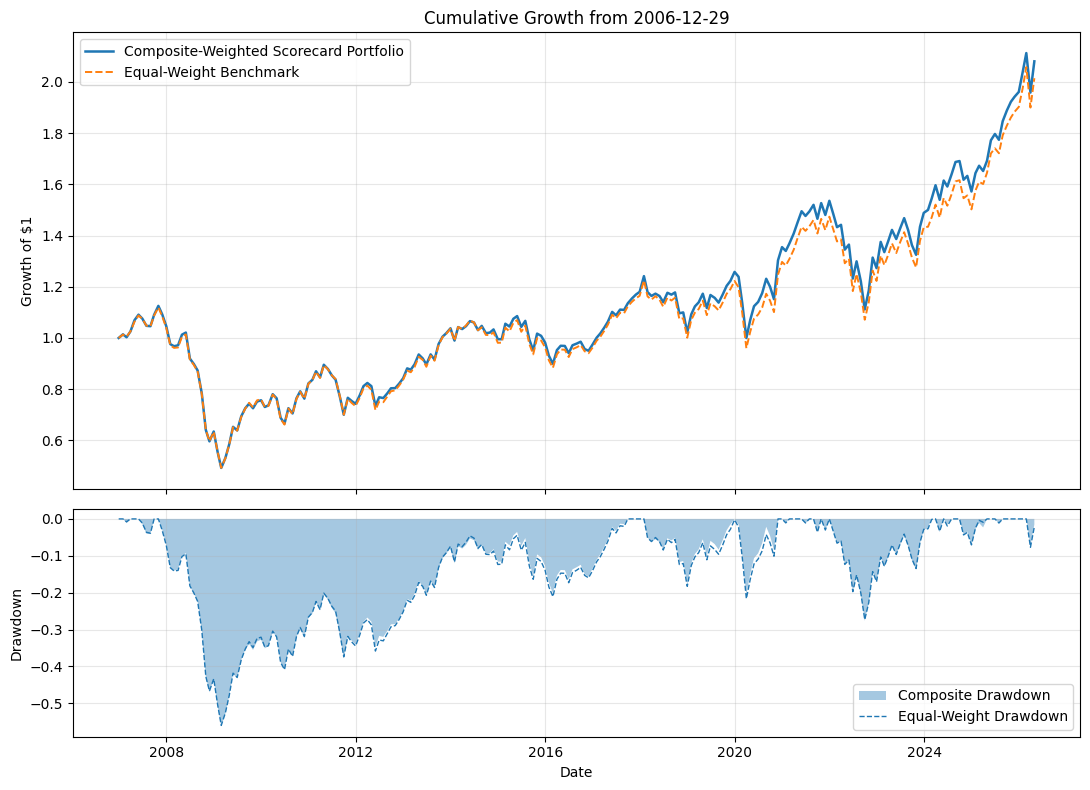


Saved: backtest_equity_curve_and_drawdown.csv


In [26]:
# Equity curve, drawdown and sub-period stability

BASE_PATH = "/content/drive/MyDrive/Crisil assessment"

# Clean start: all five countries must have a valid composite score
coverage_check = (
    scorecard.groupby("Date")["Composite_Score"]
    .apply(lambda s: s.notna().sum())
)

n_countries = scorecard["Country"].nunique()
first_valid_date = coverage_check[coverage_check == n_countries].index.min()

print("=" * 70)
print("WARM-UP CHECK")
print("=" * 70)
print(f"Countries required: {n_countries}")
print(f"First valid date: {first_valid_date.date()}")


# Portfolio panel

panel = scorecard.loc[
    scorecard["Date"] >= first_valid_date,
    ["Date", "Country", "Monthly_Return", "Composite_Score"]
].copy()

panel = panel.sort_values(["Country", "Date"]).reset_index(drop=True)


# Composite weights

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

panel["tilt"] = sigmoid(panel["Composite_Score"])

panel["weight_composite"] = (
    panel.groupby("Date")["tilt"]
    .transform(lambda x: x / x.sum())
)

panel["weight_equal"] = 1 / n_countries


# One-period execution lag

panel["weight_composite_lagged"] = (
    panel.groupby("Country")["weight_composite"].shift(1)
)

panel["weight_equal_lagged"] = (
    panel.groupby("Country")["weight_equal"].shift(1)
)

panel["contrib_composite"] = (
    panel["weight_composite_lagged"] * panel["Monthly_Return"]
)

panel["contrib_equal"] = (
    panel["weight_equal_lagged"] * panel["Monthly_Return"]
)


# Portfolio returns

portfolio_returns = (
    panel.groupby("Date")
    .agg(
        Composite_Return=("contrib_composite", "sum"),
        Equal_Return=("contrib_equal", "sum"),
        N_Countries=("Monthly_Return", "count")
    )
)

portfolio_returns = portfolio_returns.dropna(
    subset=["Composite_Return", "Equal_Return"]
)

print("\n" + "=" * 70)
print("PORTFOLIO SIMULATION")
print("=" * 70)
print(f"Months simulated: {len(portfolio_returns)}")
print(
    f"Date range: {portfolio_returns.index.min().date()} "
    f"to {portfolio_returns.index.max().date()}"
)


# Cumulative returns

portfolio_returns["Composite_Cumulative"] = (
    1 + portfolio_returns["Composite_Return"]
).cumprod()

portfolio_returns["Equal_Cumulative"] = (
    1 + portfolio_returns["Equal_Return"]
).cumprod()


# Drawdown

def compute_drawdown(cumulative):
    return cumulative / cumulative.cummax() - 1

portfolio_returns["Composite_Drawdown"] = compute_drawdown(
    portfolio_returns["Composite_Cumulative"]
)

portfolio_returns["Equal_Drawdown"] = compute_drawdown(
    portfolio_returns["Equal_Cumulative"]
)

max_dd_composite = portfolio_returns["Composite_Drawdown"].min()
max_dd_equal = portfolio_returns["Equal_Drawdown"].min()

print("\n" + "=" * 70)
print("MAXIMUM DRAWDOWN")
print("=" * 70)
print(f"Composite: {max_dd_composite:.1%}")
print(f"Equal-weight: {max_dd_equal:.1%}")


# Performance summary

def summarize_performance(returns, label):
    returns = returns.dropna()

    ann_return = (
        (1 + returns).prod() ** (12 / len(returns)) - 1
    )
    ann_vol = returns.std() * np.sqrt(12)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    print(f"\n--- {label} ---")
    print(f"Annualized return: {ann_return:.2%}")
    print(f"Annualized volatility: {ann_vol:.2%}")
    print(f"Sharpe ratio: {sharpe:.2f}")

    return {
        "Ann_Return": ann_return,
        "Ann_Vol": ann_vol,
        "Sharpe": sharpe
    }


print("\n" + "=" * 70)
print("FULL-SAMPLE PERFORMANCE")
print("=" * 70)

perf_composite = summarize_performance(
    portfolio_returns["Composite_Return"],
    "Composite-Weighted Portfolio"
)

perf_equal = summarize_performance(
    portfolio_returns["Equal_Return"],
    "Equal-Weight Benchmark"
)

correlation = portfolio_returns["Composite_Return"].corr(
    portfolio_returns["Equal_Return"]
)

excess_return = (
    portfolio_returns["Composite_Cumulative"].iloc[-1]
    / portfolio_returns["Equal_Cumulative"].iloc[-1]
    - 1
)

print(f"\nCorrelation: {correlation:.3f}")
print(f"Cumulative excess growth: {excess_return:.1%}")


# Sub-period stability

dates_sorted = portfolio_returns.index.sort_values()
midpoint = dates_sorted[len(dates_sorted) // 2]

first_half = portfolio_returns.loc[:midpoint]
second_half = portfolio_returns.loc[midpoint:]

print("\n" + "=" * 70)
print("SUB-PERIOD STABILITY")
print("=" * 70)

print(f"\nFirst half: {first_half.index.min().date()} to {first_half.index.max().date()}")
summarize_performance(
    first_half["Composite_Return"],
    "Composite — First Half"
)
summarize_performance(
    first_half["Equal_Return"],
    "Equal-weight — First Half"
)

print(f"\nSecond half: {second_half.index.min().date()} to {second_half.index.max().date()}")
summarize_performance(
    second_half["Composite_Return"],
    "Composite — Second Half"
)
summarize_performance(
    second_half["Equal_Return"],
    "Equal-weight — Second Half"
)


# Selected historical windows

crisis_window = portfolio_returns.loc["2008-01-01":"2009-12-31"]
calm_window = portfolio_returns.loc["2013-01-01":"2019-12-31"]

if len(crisis_window) > 0:
    print(f"\nCrisis window (2008–2009), N={len(crisis_window)}")
    summarize_performance(
        crisis_window["Composite_Return"],
        "Composite — Crisis"
    )
    summarize_performance(
        crisis_window["Equal_Return"],
        "Equal-weight — Crisis"
    )

if len(calm_window) > 0:
    print(f"\nCalm window (2013–2019), N={len(calm_window)}")
    summarize_performance(
        calm_window["Composite_Return"],
        "Composite — Calm"
    )
    summarize_performance(
        calm_window["Equal_Return"],
        "Equal-weight — Calm"
    )


# Equity curve and drawdown

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(11, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

ax1.plot(
    portfolio_returns.index,
    portfolio_returns["Composite_Cumulative"],
    label="Composite-Weighted Scorecard Portfolio",
    linewidth=1.8
)

ax1.plot(
    portfolio_returns.index,
    portfolio_returns["Equal_Cumulative"],
    label="Equal-Weight Benchmark",
    linewidth=1.4,
    linestyle="--"
)

ax1.set_title(
    f"Cumulative Growth from {first_valid_date.date()}"
)
ax1.set_ylabel("Growth of $1")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.fill_between(
    portfolio_returns.index,
    portfolio_returns["Composite_Drawdown"],
    0,
    alpha=0.4,
    label="Composite Drawdown"
)

ax2.plot(
    portfolio_returns.index,
    portfolio_returns["Equal_Drawdown"],
    linewidth=1,
    linestyle="--",
    label="Equal-Weight Drawdown"
)

ax2.set_ylabel("Drawdown")
ax2.set_xlabel("Date")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Save

portfolio_returns.to_csv(
    f"{BASE_PATH}/backtest_equity_curve_and_drawdown.csv"
)

print("\nSaved: backtest_equity_curve_and_drawdown.csv")

CALENDAR-YEAR RELATIVE PERFORMANCE


,Composite_Return,Equal_Return,N_Months,Relative
Year,,,,
2006,0.0%,0.0%,1,0.0%
2007,4.6%,3.9%,12,0.7%
2008,-39.3%,-39.0%,12,-0.3%
2009,19.2%,19.9%,12,-0.7%
2010,8.7%,8.0%,12,0.7%
2011,-9.7%,-10.6%,12,1.0%
2012,13.4%,14.1%,12,-0.7%
2013,23.1%,23.8%,12,-0.6%
2014,-4.1%,-5.3%,12,1.2%



Composite beat equal-weight in 11/21 calendar years (52%).


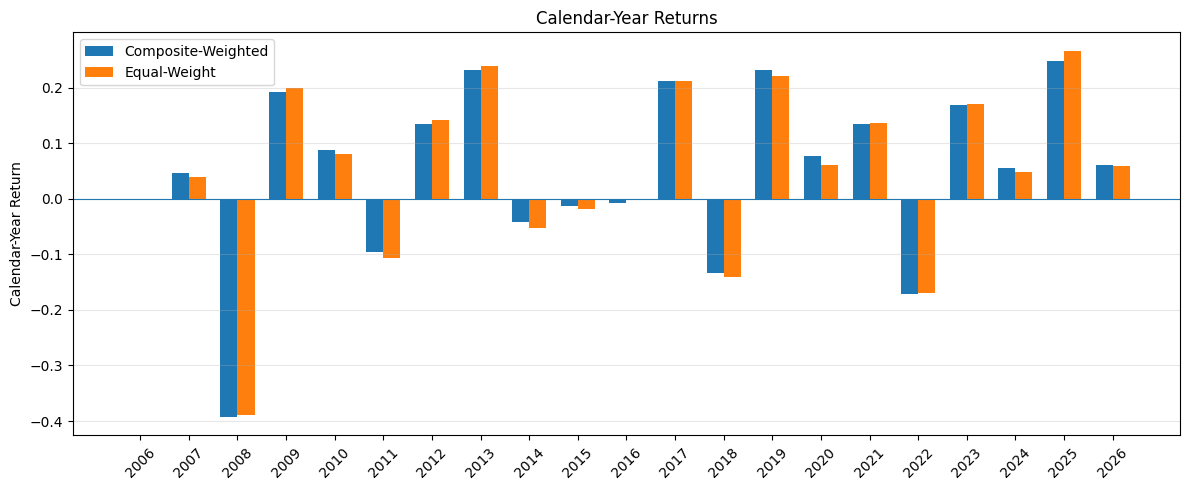


ROLLING 12-MONTH RELATIVE PERFORMANCE
Composite ahead in 51.8% of rolling 12M windows (N=222)
Mean relative return: 0.14%
Worst: -2.06% (ending 2013-05-31)
Best: 2.30% (ending 2020-08-31)


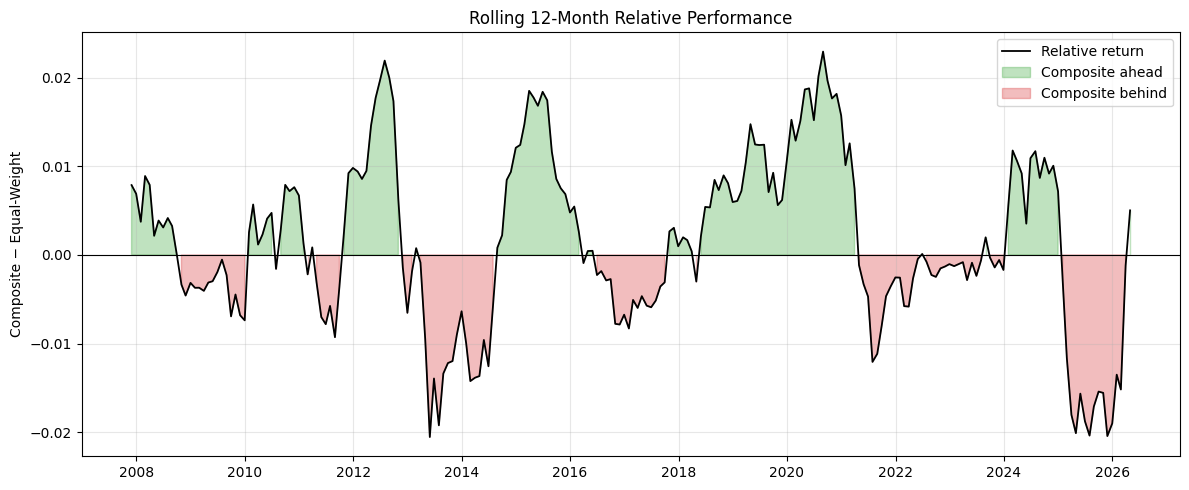

In [27]:
# Calendar-year and rolling 12-month relative performance

pr = portfolio_returns.copy()
pr["Year"] = pr.index.year


# Calendar-year returns

yearly = (
    pr.groupby("Year")
    .agg(
        Composite_Return=("Composite_Return", lambda x: (1 + x).prod() - 1),
        Equal_Return=("Equal_Return", lambda x: (1 + x).prod() - 1),
        N_Months=("Composite_Return", "count")
    )
)

yearly["Relative"] = (
    yearly["Composite_Return"] - yearly["Equal_Return"]
)

print("=" * 70)
print("CALENDAR-YEAR RELATIVE PERFORMANCE")
print("=" * 70)

display(
    yearly.style.format({
        "Composite_Return": "{:.1%}",
        "Equal_Return": "{:.1%}",
        "Relative": "{:.1%}",
        "N_Months": "{:.0f}"
    })
)

years_won = (yearly["Relative"] > 0).sum()

print(
    f"\nComposite beat equal-weight in "
    f"{years_won}/{len(yearly)} calendar years "
    f"({years_won / len(yearly):.0%})."
)


# Calendar-year chart

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(yearly))
width = 0.35

ax.bar(
    x - width / 2,
    yearly["Composite_Return"],
    width,
    label="Composite-Weighted"
)

ax.bar(
    x + width / 2,
    yearly["Equal_Return"],
    width,
    label="Equal-Weight"
)

ax.axhline(0, linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(yearly.index, rotation=45)
ax.set_ylabel("Calendar-Year Return")
ax.set_title("Calendar-Year Returns")
ax.legend()
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


# Rolling 12-month relative performance

pr["Composite_Roll12"] = (
    (1 + pr["Composite_Return"])
    .rolling(12)
    .apply(np.prod, raw=True) - 1
)

pr["Equal_Roll12"] = (
    (1 + pr["Equal_Return"])
    .rolling(12)
    .apply(np.prod, raw=True) - 1
)

pr["Relative_Roll12"] = (
    pr["Composite_Roll12"] - pr["Equal_Roll12"]
)

roll = pr["Relative_Roll12"].dropna()

print("\n" + "=" * 70)
print("ROLLING 12-MONTH RELATIVE PERFORMANCE")
print("=" * 70)

print(
    f"Composite ahead in {(roll > 0).mean():.1%} "
    f"of rolling 12M windows (N={len(roll)})"
)

print(f"Mean relative return: {roll.mean():.2%}")
print(
    f"Worst: {roll.min():.2%} "
    f"(ending {roll.idxmin().date()})"
)
print(
    f"Best: {roll.max():.2%} "
    f"(ending {roll.idxmax().date()})"
)


# Rolling relative-performance chart

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    roll.index,
    roll,
    color="black",
    linewidth=1.3,
    label="Relative return"
)

ax.axhline(0, linewidth=0.8, color="black")

ax.fill_between(
    roll.index,
    roll,
    0,
    where=roll >= 0,
    color="tab:green",
    alpha=0.3,
    label="Composite ahead"
)

ax.fill_between(
    roll.index,
    roll,
    0,
    where=roll < 0,
    color="tab:red",
    alpha=0.3,
    label="Composite behind"
)

ax.set_ylabel("Composite − Equal-Weight")
ax.set_title("Rolling 12-Month Relative Performance")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Supporting Charts

Visualizations of pillar scores over time, composite score by country, and country rank evolution - supporting the scorecard construction and backtest results above.

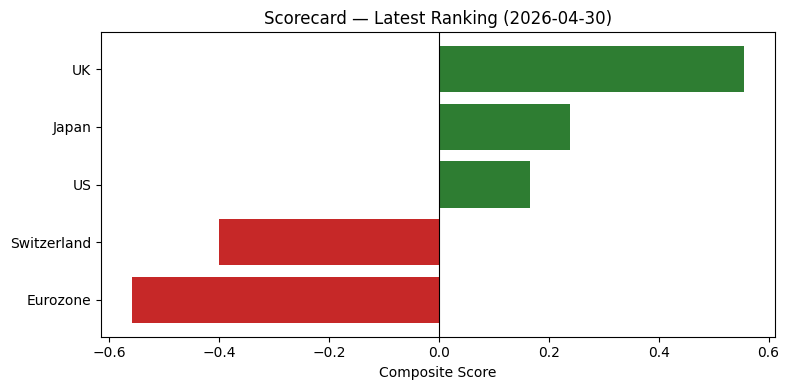

In [28]:
import matplotlib.pyplot as plt

latest = scorecard[scorecard["Date"] == scorecard["Date"].max()].copy()
latest = latest.sort_values("Composite_Score", ascending=True)

colors = ["#2E7D32" if s > 0 else "#C62828" for s in latest["Composite_Score"]]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(latest["Country"], latest["Composite_Score"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Composite Score")
ax.set_title(f"Scorecard — Latest Ranking ({latest['Date'].max().date()})")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/slide_ranking_bar.png", dpi=200)
plt.show()

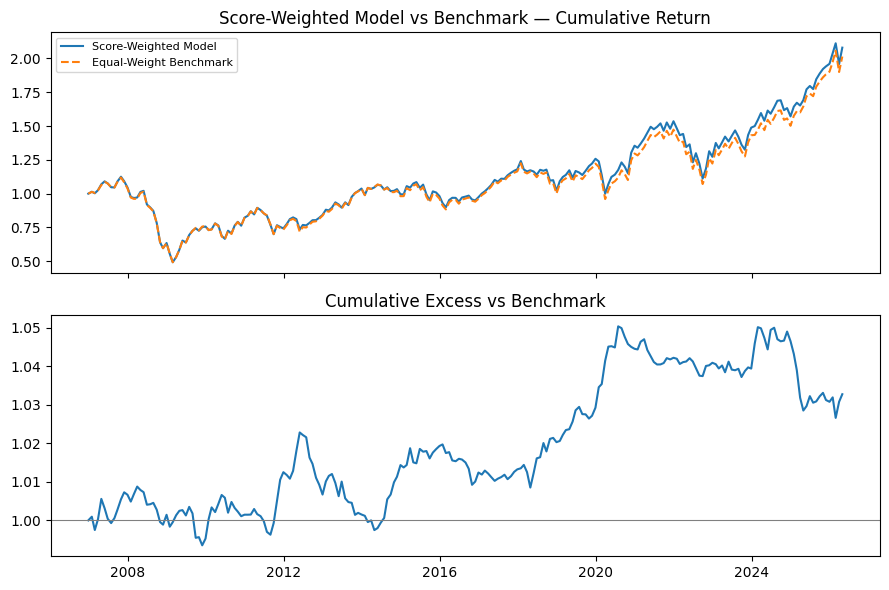

In [29]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax1.plot(portfolio_returns.index, portfolio_returns["Composite_Cumulative"], label="Score-Weighted Model")
ax1.plot(portfolio_returns.index, portfolio_returns["Equal_Cumulative"], label="Equal-Weight Benchmark", linestyle="--")
ax1.set_title("Score-Weighted Model vs Benchmark — Cumulative Return")
ax1.legend(fontsize=8)

excess = portfolio_returns["Composite_Cumulative"] / portfolio_returns["Equal_Cumulative"]
ax2.plot(portfolio_returns.index, excess, color="tab:blue")
ax2.axhline(1, color="grey", linewidth=0.8)
ax2.set_title("Cumulative Excess vs Benchmark")

plt.tight_layout()
plt.savefig(f"{BASE_PATH}/slide_cumulative_excess.png", dpi=200)
plt.show()

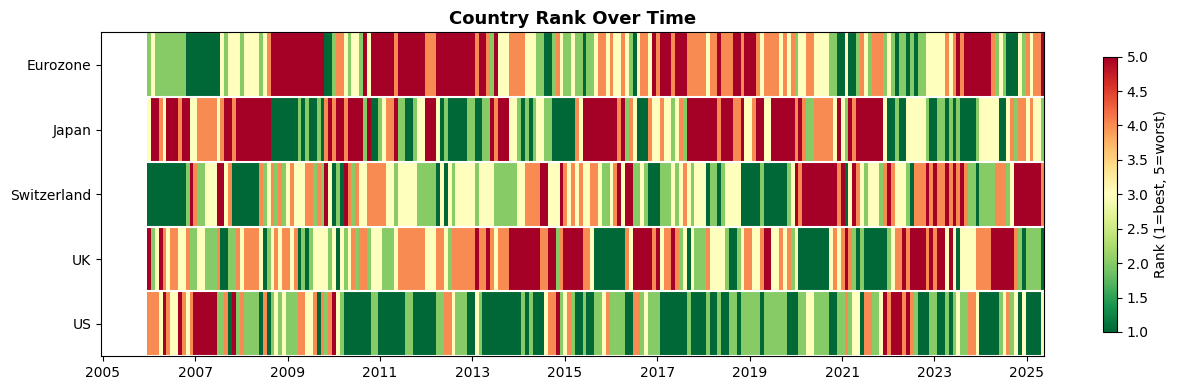

In [30]:
rank_wide = scorecard.pivot(index="Date", columns="Country", values="Country_Rank")

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(rank_wide.T.values, aspect="auto", cmap="RdYlGn_r", vmin=1, vmax=5)

ax.set_yticks(range(len(rank_wide.columns)))
ax.set_yticklabels(rank_wide.columns)

# Clean date formatting: just the year, evenly spaced, no time component
tick_step = 24
tick_positions = range(0, len(rank_wide.index), tick_step)
tick_labels = [rank_wide.index[i].strftime("%Y") for i in tick_positions]
ax.set_xticks(list(tick_positions))
ax.set_xticklabels(tick_labels, rotation=0, ha="center")

# Light gridlines between country rows for readability
ax.set_yticks(np.arange(-0.5, len(rank_wide.columns), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="minor", length=0)

plt.colorbar(im, label="Rank (1=best, 5=worst)", shrink=0.85)
ax.set_title("Country Rank Over Time", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/slide_rank_heatmap.png", dpi=200)
plt.show()

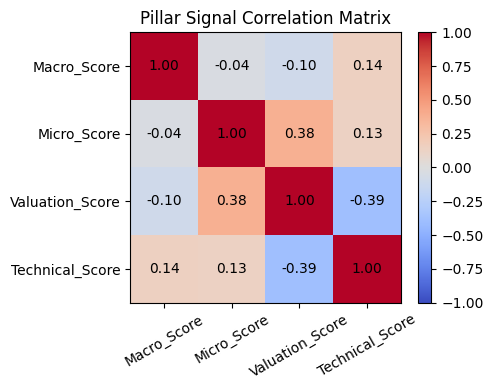

In [31]:
merged = (
    scorecard[["Date", "Country", "Macro_Score", "Micro_Score", "Valuation_Score", "Technical_Score"]]
    .dropna()
)
corr_matrix = merged[["Macro_Score", "Micro_Score", "Valuation_Score", "Technical_Score"]].corr()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(4)); ax.set_xticklabels(corr_matrix.columns, rotation=30)
ax.set_yticks(range(4)); ax.set_yticklabels(corr_matrix.columns)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{corr_matrix.iloc[i,j]:.2f}", ha="center", va="center")
plt.colorbar(im)
ax.set_title("Pillar Signal Correlation Matrix")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/slide_signal_correlation.png", dpi=200)
plt.show()

In [33]:
from scipy import stats
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Recompute IC for all 4 pillars + composite directly from the
# scorecard panel — avoids relying on variable names left over
# from separate pillar cells (which get overwritten each time,
# since every pillar cell reuses "ic_6m" as its variable name).
# ------------------------------------------------------------

def monthly_ic_from_panel(df, signal_col, return_col):
    ic = {}
    for date, g in df.groupby("Date"):
        g2 = g[[signal_col, return_col]].dropna()
        if len(g2) < 3:
            continue
        corr, _ = stats.spearmanr(g2[signal_col], g2[return_col])
        if not np.isnan(corr):
            ic[date] = corr
    return pd.Series(ic).sort_index()   # clean Series: Date -> IC (float)

# Adjust these two lines if your scorecard uses different column names
return_col = "Forward_6M" if "Forward_6M" in scorecard.columns else "fwd_return_6m"

pillar_cols = {
    "Macro (PMI)":          "Macro_Score",
    "Micro (EPS)":           "Micro_Score",
    "Valuation (P/E)":       "Valuation_Score",
    "Technical (Momentum)":  "Technical_Score",
}

ic_by_pillar = {
    label: monthly_ic_from_panel(scorecard, col, return_col)
    for label, col in pillar_cols.items()
}

ic_composite = monthly_ic_from_panel(scorecard, "Composite_Score", return_col)

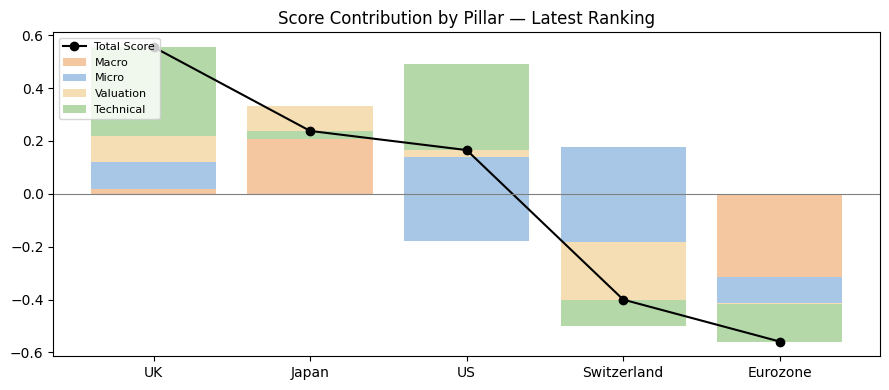

In [35]:
pillars = ["Macro_Score", "Micro_Score", "Valuation_Score", "Technical_Score"]
weights = {"Macro_Score": 0.25, "Micro_Score": 0.25, "Valuation_Score": 0.25, "Technical_Score": 0.25}

# Ordered by Composite_Score descending, matching the ranking table on Slide 3
# (rather than alphabetical) so the chart reads left-to-right as best-to-worst.
country_order = (
    latest.sort_values("Composite_Score", ascending=False)["Country"].tolist()
)

contrib = latest.set_index("Country").loc[country_order, pillars].copy()
for p in pillars:
    contrib[p] = contrib[p] * weights[p]

fig, ax = plt.subplots(figsize=(9, 4))
bottom = pd.Series(0, index=contrib.index)

# Matched to Slide 1 color scheme: Macro=peach, Micro=blue, Valuation=yellow, Technical=green
colors_map = {
    "Macro_Score": "#F4C7A1",       # peach
    "Micro_Score": "#A8C6E5",       # blue
    "Valuation_Score": "#F5DEB3",   # yellow
    "Technical_Score": "#B5D8A8"    # green
}

for p in pillars:
    ax.bar(contrib.index, contrib[p], bottom=bottom, label=p.replace("_Score", ""), color=colors_map[p])
    bottom += contrib[p]

ax.plot(contrib.index, contrib.sum(axis=1), color="black", marker="o", label="Total Score")
ax.axhline(0, color="grey", linewidth=0.8)
ax.legend(loc="upper left", fontsize=8)
ax.set_title("Score Contribution by Pillar — Latest Ranking")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/slide_contribution_bar.png", dpi=200)
plt.show()

## Investment View - Current Ranking & Recommendation

**Current ranking (2026-04-30), by Composite_Score:**

| Rank | Country | Composite Score | Rating |
|---|---|---|---|
| 1 | UK | 0.56 | Overweight |
| 2 | Japan | 0.24 | Overweight |
| 3 | US | 0.17 | Equal Weight |
| 4 | Switzerland | -0.40 | Underweight |
| 5 | Eurozone | -0.56 | Underweight |

We rate **UK** and **Japan** Overweight, **US** Equal Weight, and **Switzerland** and **Eurozone** Underweight, over a 3-6 month horizon.

**UK - Overweight.** Technical and earnings momentum both point the same way (Technical 1.35, Micro 0.41), with valuation also supportive (0.39) and macro broadly neutral. The call is price-trend and earnings-led rather than a macro upgrade, and is the highest-conviction position on the board given three of four pillars agree.

**Japan - Overweight.** Driven almost entirely by macro (1.18, the strongest PMI reading in the panel), with valuation working against the position (-0.50). This is a top-down growth-regime call rather than a value call, and conviction should be read as narrower than the UK's, resting on one dominant pillar rather than broad pillar agreement.

**US - Equal Weight.** Fundamentals are the best in the panel - Micro (1.27) and Valuation (1.41) are both the strongest scores across all five markets - but this is offset by the weakest Technical score (-1.30). Attractive fundamentals against a deteriorating price trend nets out close to neutral; we would look for technical confirmation before moving this to Overweight.

**Switzerland and Eurozone - Underweight.** Both are weighed down primarily by weak earnings and valuation momentum; Eurozone additionally carries the weakest macro score in the panel. Neither position is being driven by a single outlier pillar, which is a more durable basis for an Underweight than a one-factor call.

**Conviction and backtest support.** The composite score's 6-month rank IC averages 0.12 (HAC p≈0.06), and historically the top-ranked country has outperformed the bottom-ranked country by ~1.7% over 6 months (Sharpe ≈0.28, HAC p≈0.09). This is directionally consistent evidence at the edge of conventional statistical significance - sufficient to support the relative tilts above, but not to treat any single position as high-conviction in isolation.